In [1]:
import sys
import os

# Adjust the path to point to your src directory
sys.path.insert(0, os.path.abspath('../../src'))

from dionexus.import_data import load_all_data 

ds = load_all_data("../../data/sukinda_diluted_23feb25")

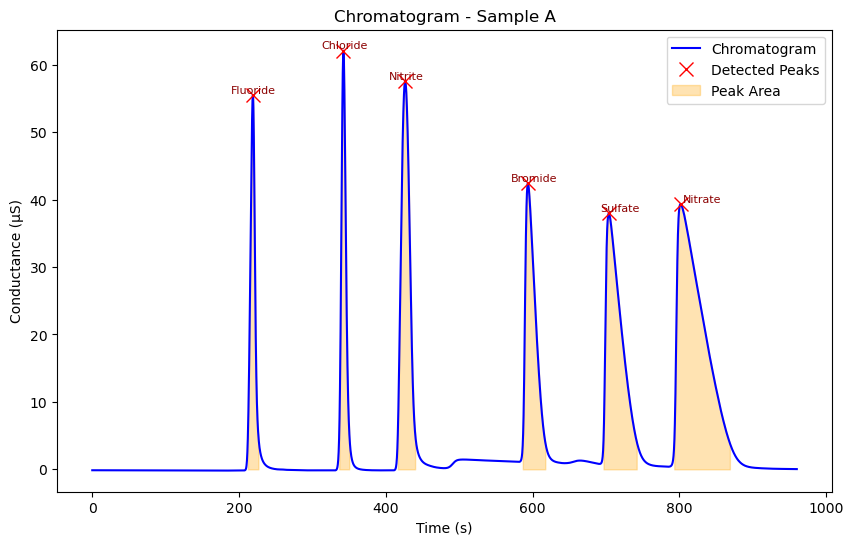

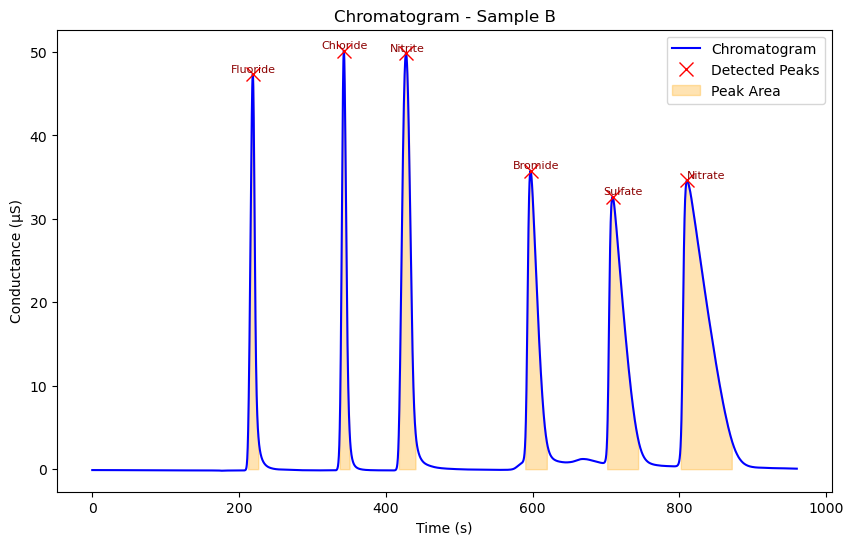

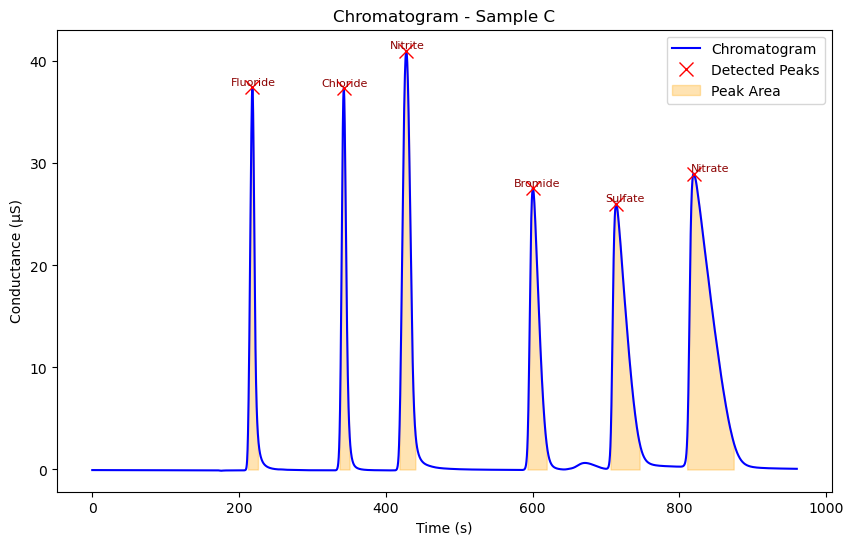

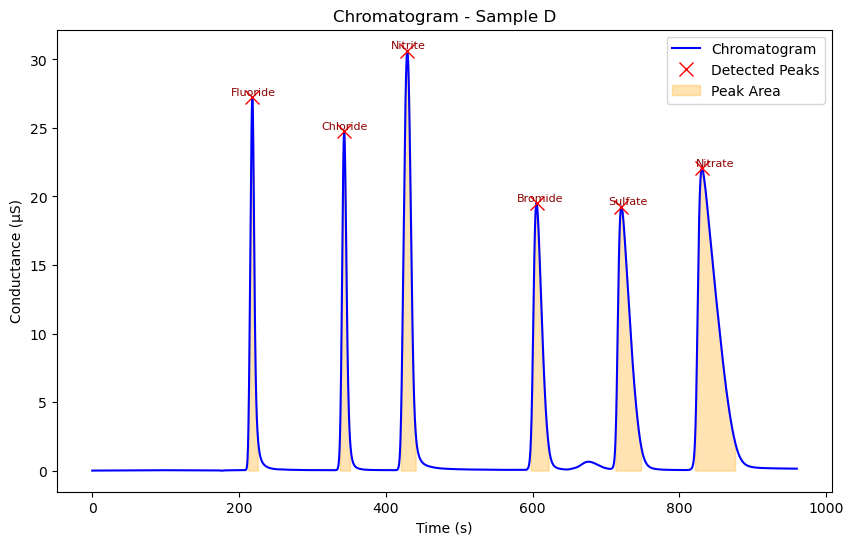

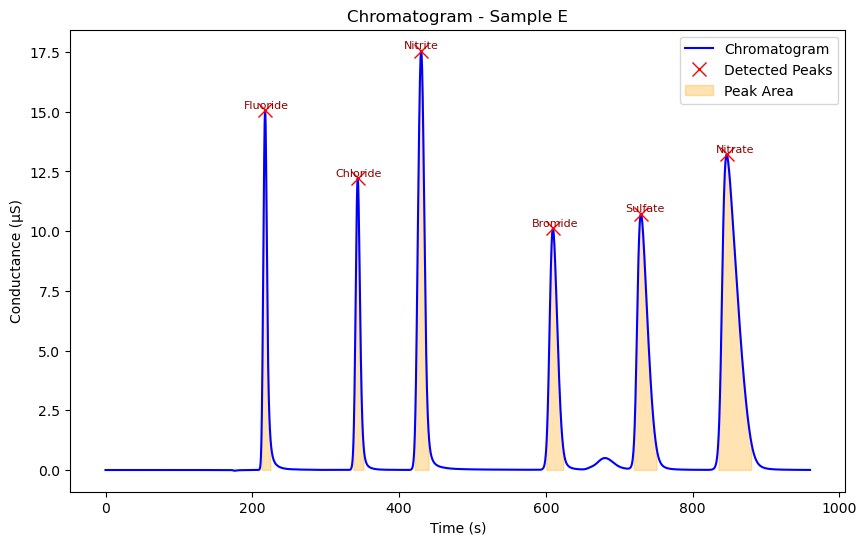

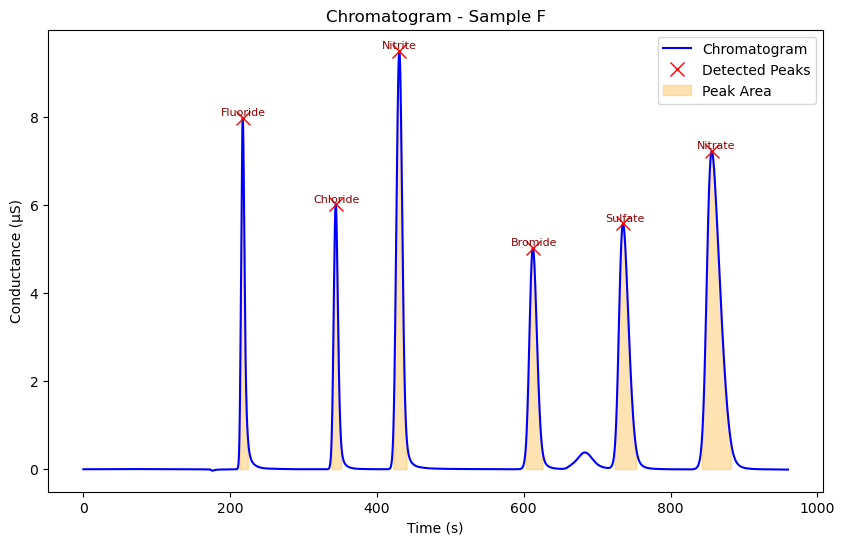

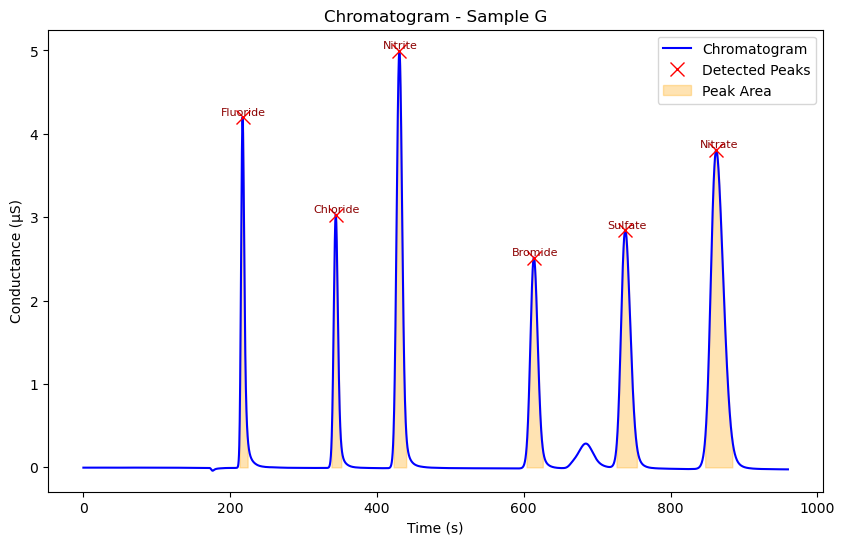

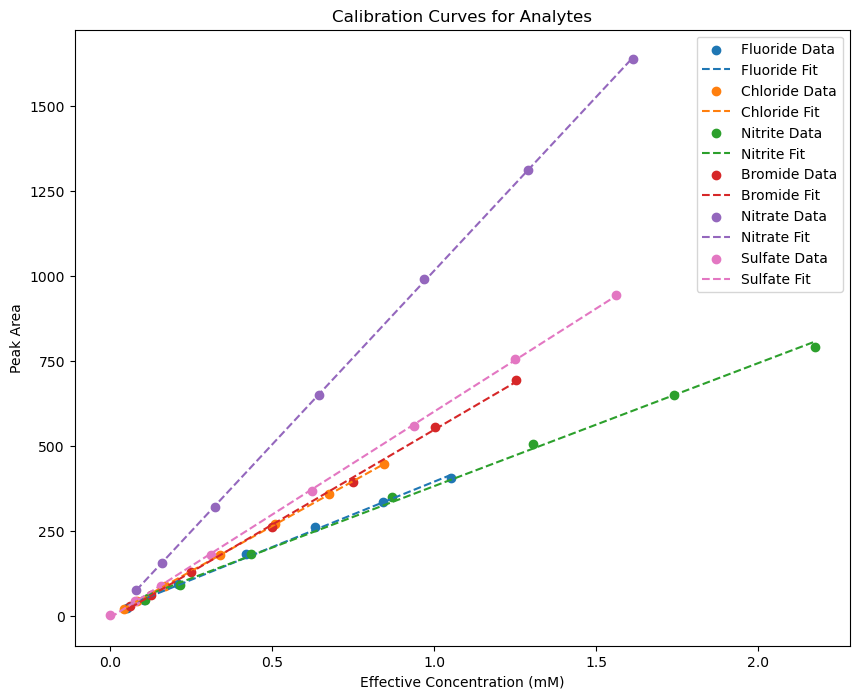

In [2]:
import xarray as xr
from ionchrom_analysis import IonChromatographyAnalyzer

# Initialize the analyzer with the dataset and calibration CSV file
analyzer = IonChromatographyAnalyzer(ds, calibration_file="../../data/virtual_columns/18mM.csv")

# 1. Detect peaks in all samples (using default parameters)
#analyzer.detect_peaks(min_height=0.5, prominence=0.05, distance=5, min_sharpness=0.1)

# Define your detection criteria for calibration and unknown samples:
calibration_detection_params = {
    'min_height': 0.1,
    'prominence': 0.05,
    'distance': 5,
    #'max_width': 10,
    'min_sharpness': 0.1,
    'width_rel': 0.911
}

unknown_detection_params = {
    'min_height': 0.1,
    'prominence': 0.05,
    'distance': 5,
    #'max_width': 15,
    'min_sharpness': 0.0001,
    'width_rel': 0.8
}

# Suppose your calibration samples are 'A' through 'G'
calibration_samples = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# Detect peaks with different criteria for calibration and unknown samples:
analyzer.detect_peaks(calibration_samples=calibration_samples,
                      calib_criteria=calibration_detection_params,
                      unknown_criteria=unknown_detection_params)

# 2. Calibrate using known calibration samples (named 'A' to 'G')
analyzer.calibrate(calibration_samples=['A', 'B', 'C', 'D', 'E', 'F', 'G'])

# Calculate the peak area for all detected peaks
analyzer.calculate_peak_area()

# 3. Assign peaks in other samples using a 30-second retention time tolerance
analyzer.assign_peaks(ret_time_tolerance=40)

# 4. Apply quality filtering (here filtering based on asymmetry if computed)
analyzer.filter_peaks(max_asymmetry=2.0)

# 5. Retrieve results as a DataFrame and as an xarray Dataset
results_ds = analyzer.get_results_xarray()

for sample in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    analyzer.plot_chromatogram(sample=sample)

# Define the dilution factors (e.g., for calibration samples A-G)
dilution_factors = [1, 0.8, 0.6, 0.4, 0.2, 0.1, 0.05, 0]

# Calculate calibration curves; the method will also plot the curves.
calibration_fit = analyzer.calculate_calibration_curve("gabby_standards.csv", dilution_factors, 
                                                       calibration_samples=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'STD BLANK'])

# 6. Calculate the concentration of unknown samples
results_ds = analyzer.calculate_concentrations(results_ds, calibration_fit)

In [3]:
results_ds

<xarray.Dataset> Size: 63kB
Dimensions:              (sample: 78, peak: 8)
Coordinates:
  * sample               (sample) <U11 3kB 'A' 'A_1' ... 'STD BLANK_1'
  * peak                 (peak) int64 64B 0 1 2 3 4 5 6 7
Data variables:
    peak_time            (sample, peak) float64 5kB 218.8 342.4 ... nan nan
    peak_height          (sample, peak) float64 5kB 55.52 62.09 ... nan nan
    prominence           (sample, peak) float64 5kB 55.68 62.25 ... nan nan
    width                (sample, peak) float64 5kB 14.48 13.73 ... nan nan
    left_time            (sample, peak) float64 5kB 212.0 336.6 ... nan nan
    right_time           (sample, peak) float64 5kB 226.5 350.3 ... nan nan
    sharpness            (sample, peak) float64 5kB 3.835 4.522 ... nan nan
    peak_area            (sample, peak) float64 5kB 406.4 445.4 ... nan nan
    assigned_analyte     (sample, peak) object 5kB 'Fluoride' 'Chloride' ... nan
    QC_flag              (sample, peak) float64 5kB 1.0 1.0 1.0 ... nan nan nan
    concentration        (sample, peak) float64 5kB 1.031 0.8429 ... nan nan
    concentration_error  (sample, peak) float64 5kB 0.02163 0.003031 ... nan nan

In [4]:
results_ds

<xarray.Dataset> Size: 63kB
Dimensions:              (sample: 78, peak: 8)
Coordinates:
  * sample               (sample) <U11 3kB 'A' 'A_1' ... 'STD BLANK_1'
  * peak                 (peak) int64 64B 0 1 2 3 4 5 6 7
Data variables:
    peak_time            (sample, peak) float64 5kB 218.8 342.4 ... nan nan
    peak_height          (sample, peak) float64 5kB 55.52 62.09 ... nan nan
    prominence           (sample, peak) float64 5kB 55.68 62.25 ... nan nan
    width                (sample, peak) float64 5kB 14.48 13.73 ... nan nan
    left_time            (sample, peak) float64 5kB 212.0 336.6 ... nan nan
    right_time           (sample, peak) float64 5kB 226.5 350.3 ... nan nan
    sharpness            (sample, peak) float64 5kB 3.835 4.522 ... nan nan
    peak_area            (sample, peak) float64 5kB 406.4 445.4 ... nan nan
    assigned_analyte     (sample, peak) object 5kB 'Fluoride' 'Chloride' ... nan
    QC_flag              (sample, peak) float64 5kB 1.0 1.0 1.0 ... nan nan nan
    concentration        (sample, peak) float64 5kB 1.031 0.8429 ... nan nan
    concentration_error  (sample, peak) float64 5kB 0.02163 0.003031 ... nan nan

In [5]:
calibration_fit

{'Fluoride': {'slope': np.float64(385.03071012872556),
  'intercept': np.float64(9.617565302144783),
  'r_value': np.float64(0.998900259223346),
  'p_value': np.float64(7.69881262075278e-08),
  'std_err': np.float64(8.082188376942211)},
 'Chloride': {'slope': np.float64(529.6077670685731),
  'intercept': np.float64(-0.9945370129352398),
  'r_value': np.float64(0.9999676696806262),
  'p_value': np.float64(1.1414878812503365e-11),
  'std_err': np.float64(1.9045828511601566)},
 'Nitrite': {'slope': np.float64(361.8122579759922),
  'intercept': np.float64(19.696017888007248),
  'r_value': np.float64(0.9990992511532815),
  'p_value': np.float64(4.674697667985473e-08),
  'std_err': np.float64(6.8724039121617455)},
 'Bromide': {'slope': np.float64(558.1483769410271),
  'intercept': np.float64(-11.04353613077734),
  'r_value': np.float64(0.9994515231621053),
  'p_value': np.float64(1.3527637313653689e-08),
  'std_err': np.float64(8.270609490330493)},
 'Nitrate': {'slope': np.float64(1022.34209

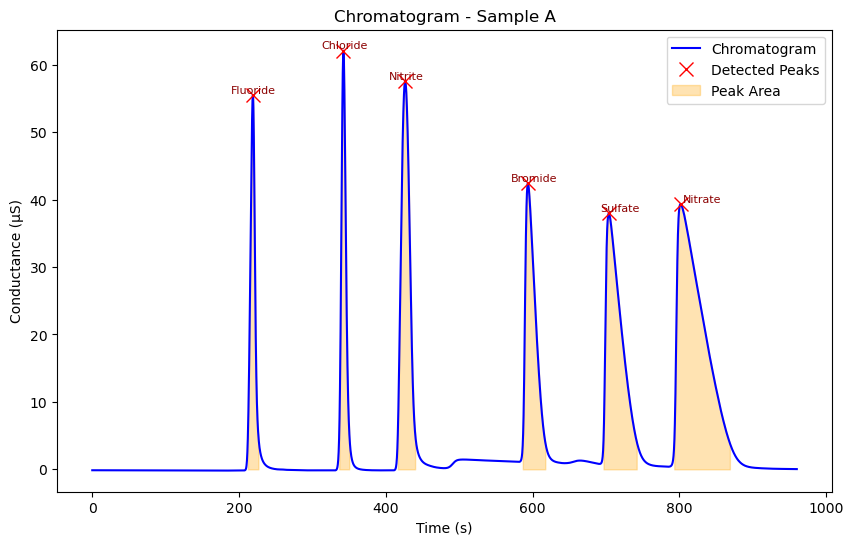

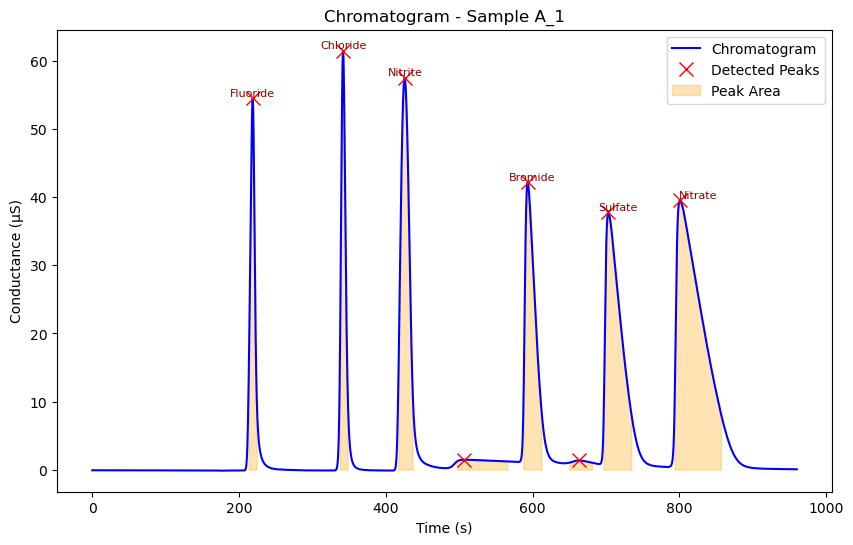

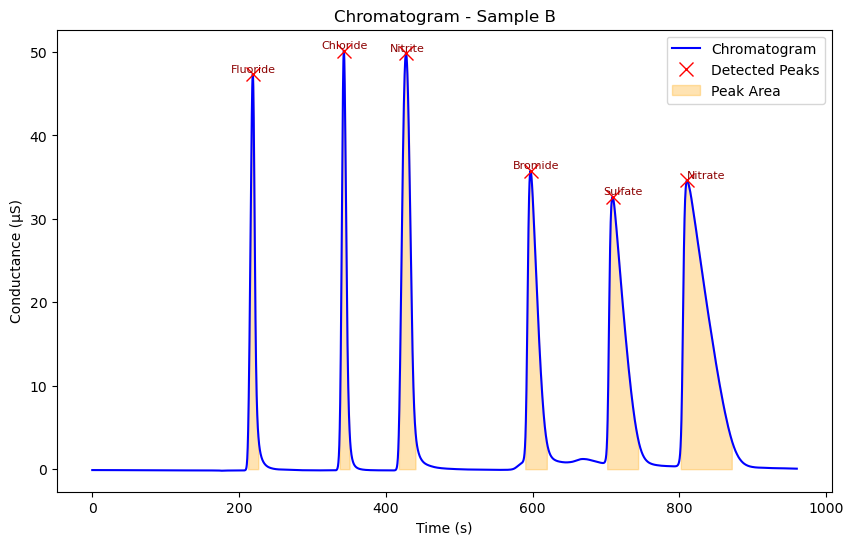

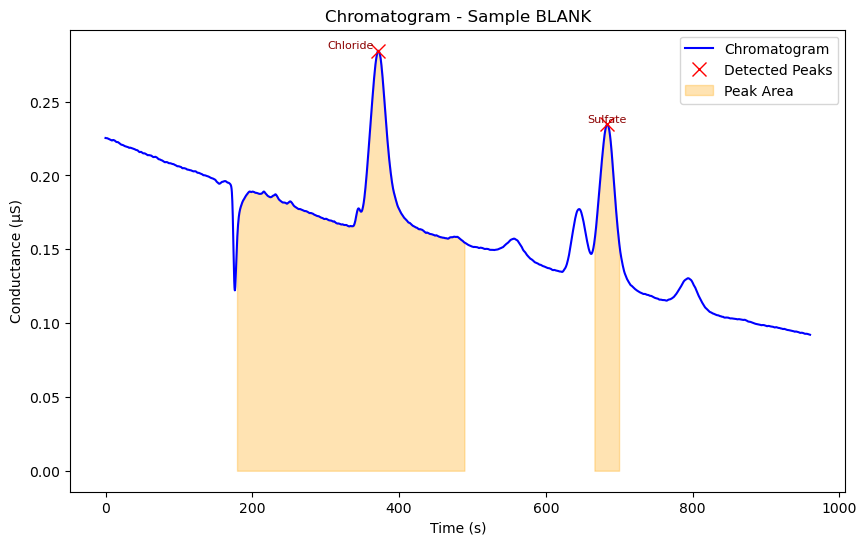

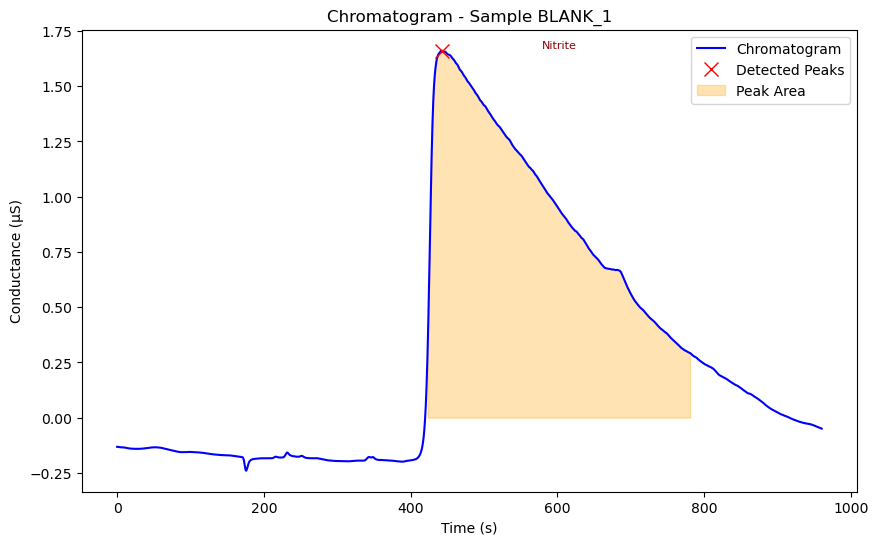

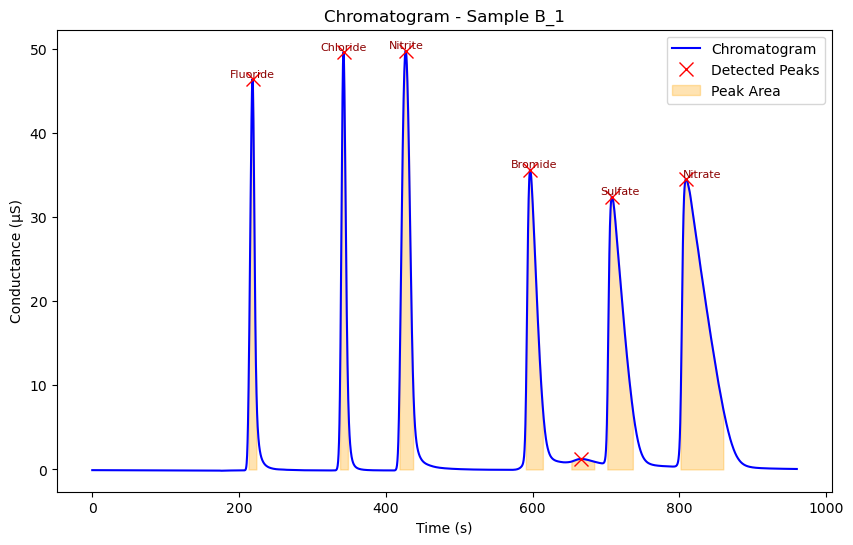

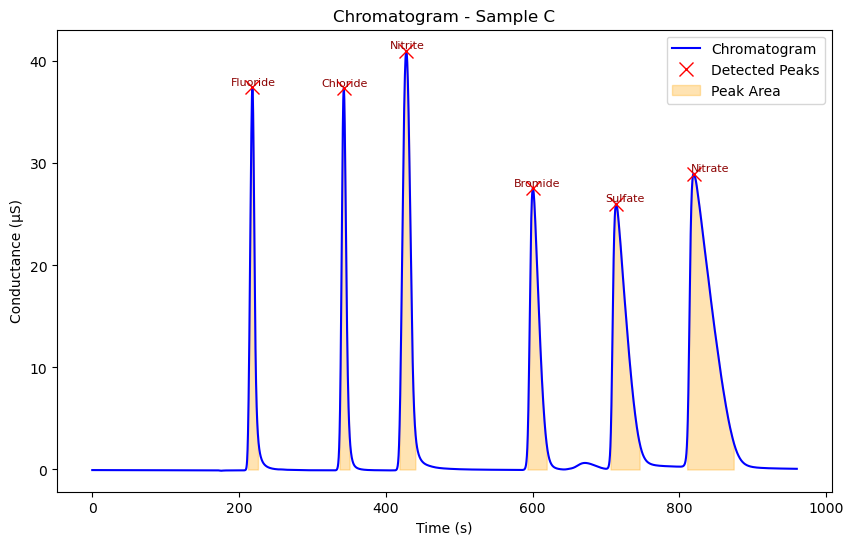

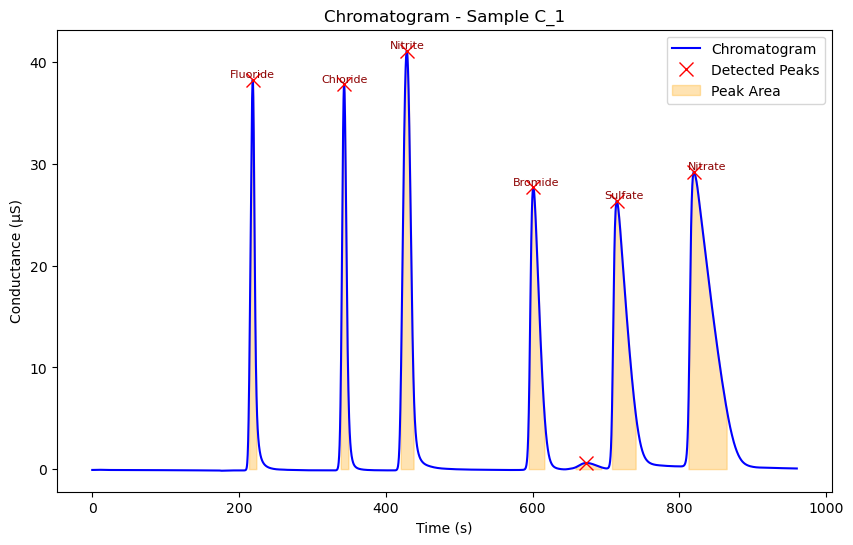

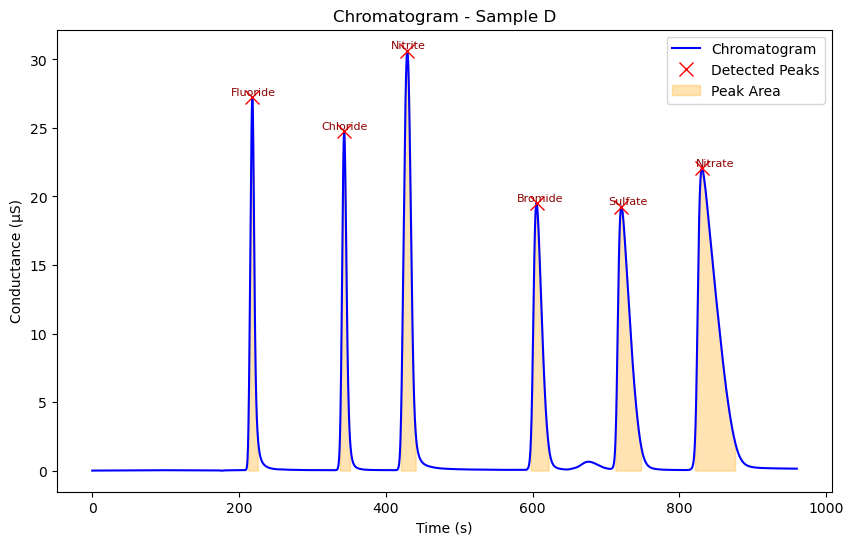

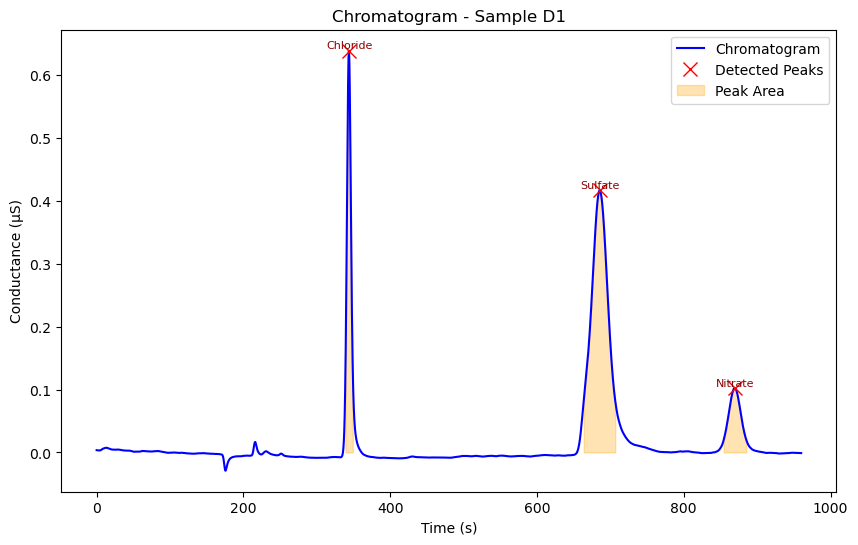

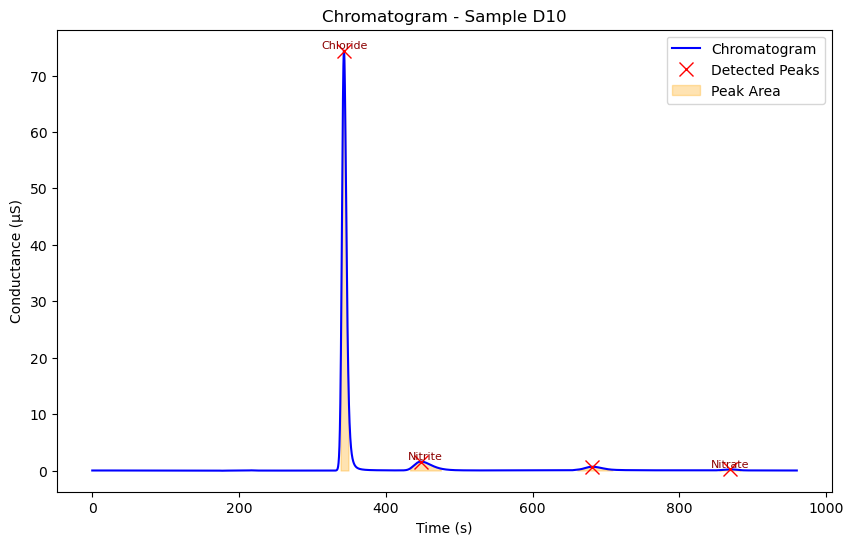

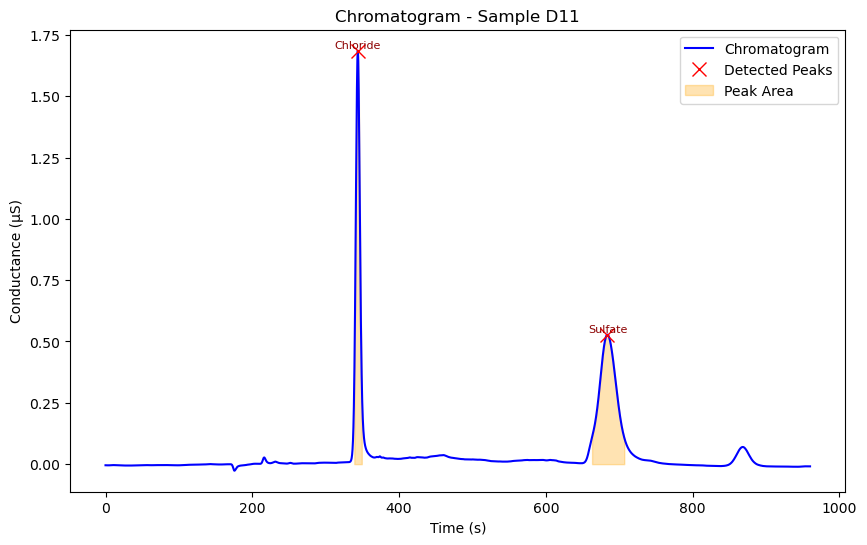

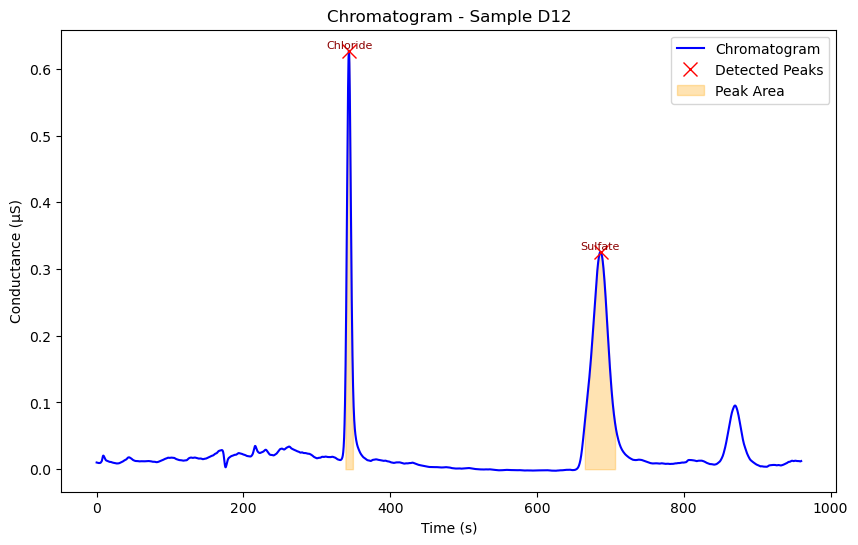

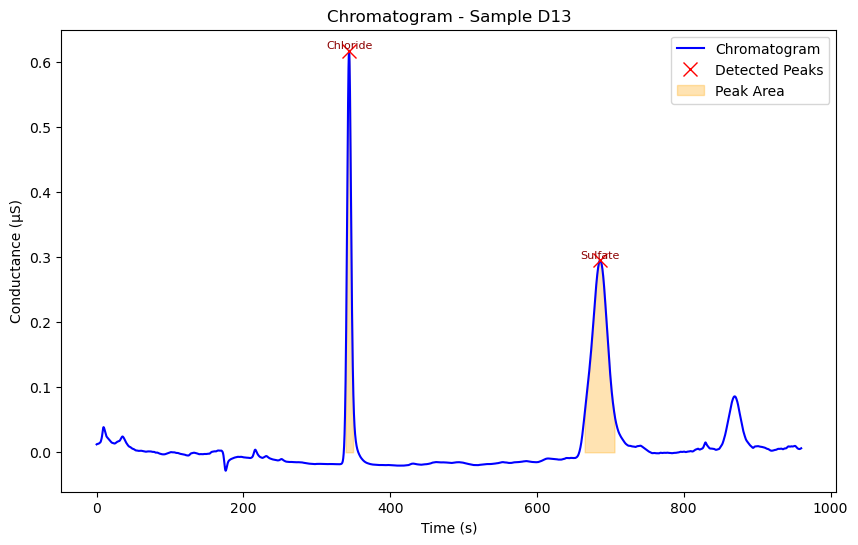

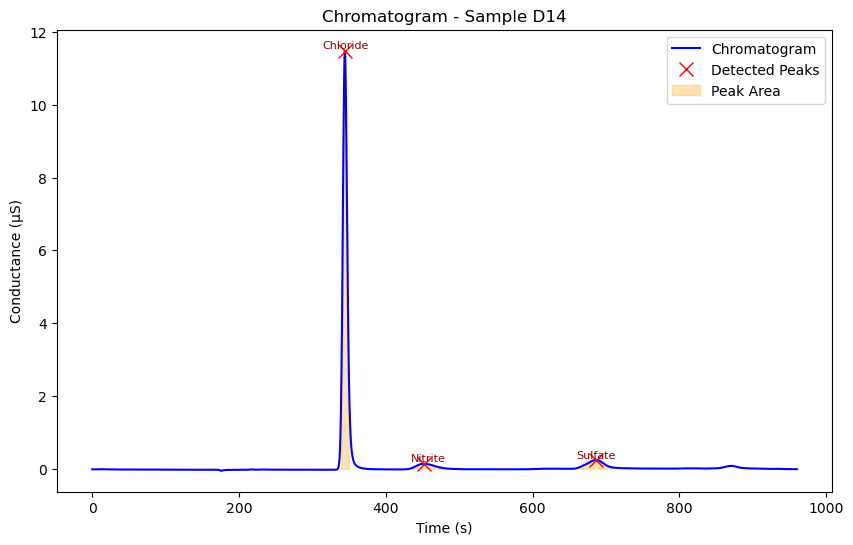

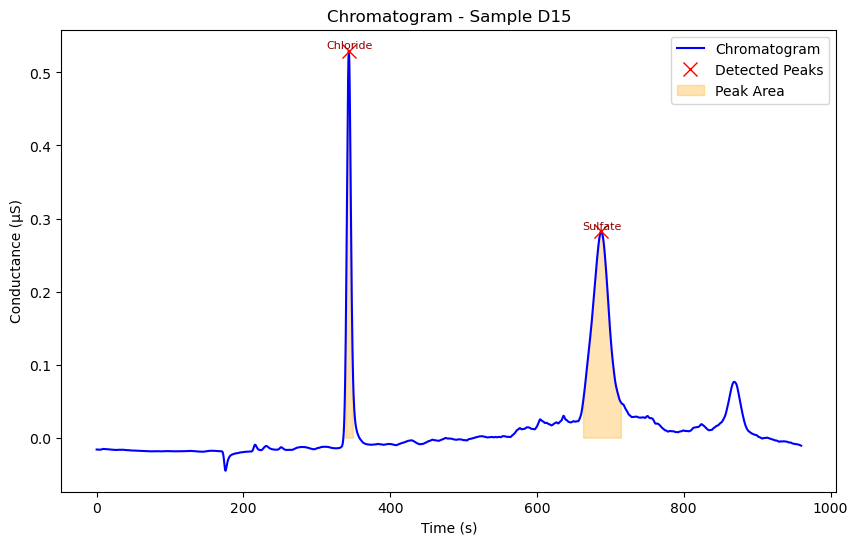

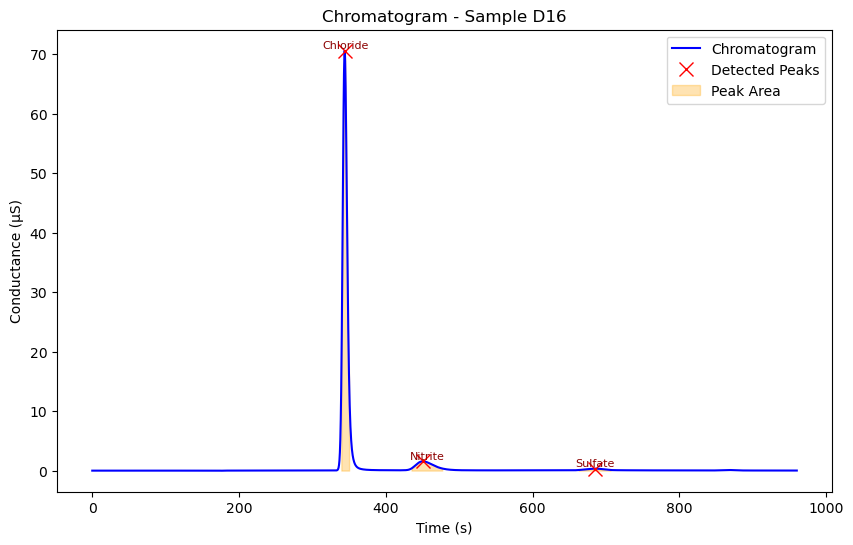

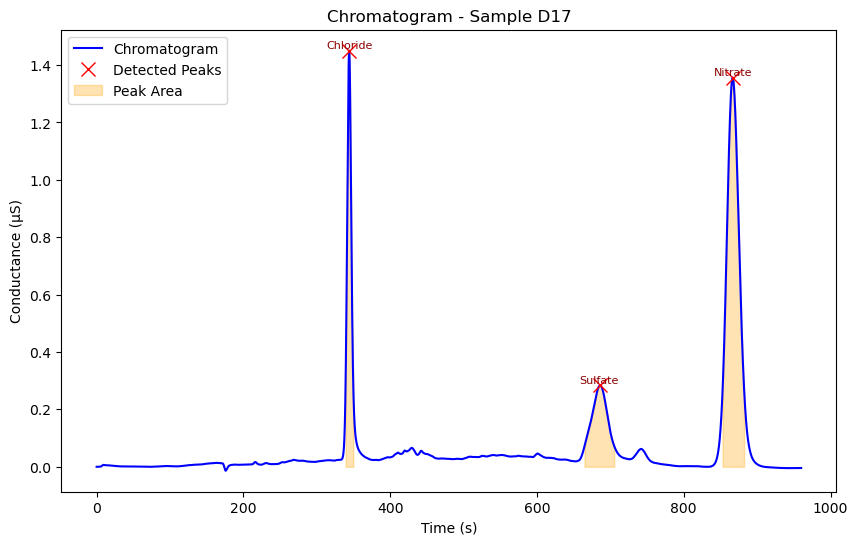

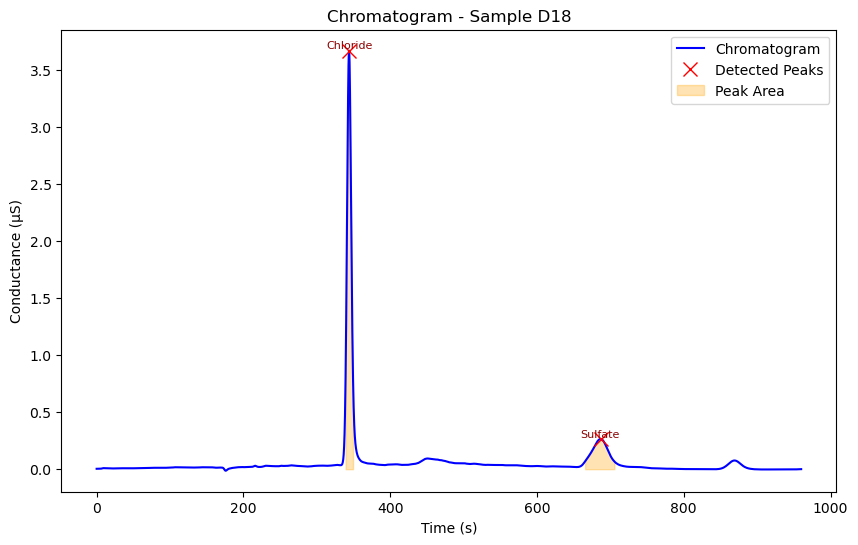

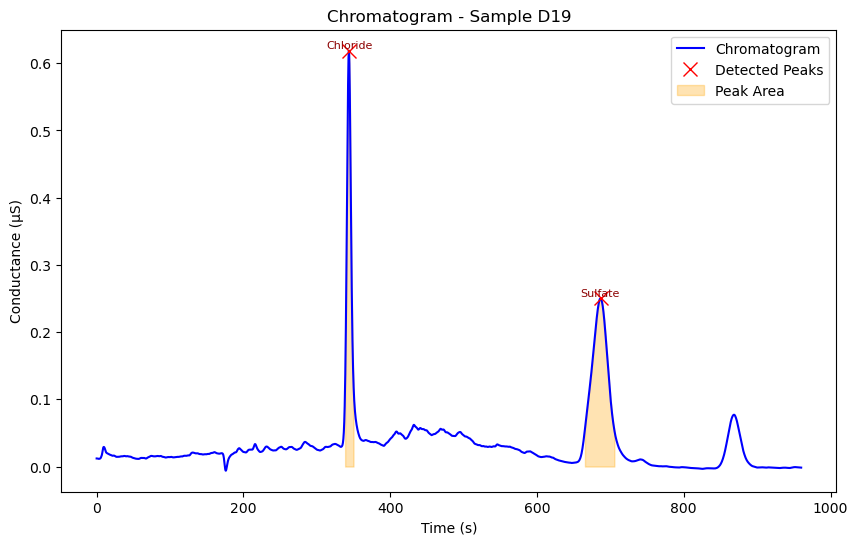

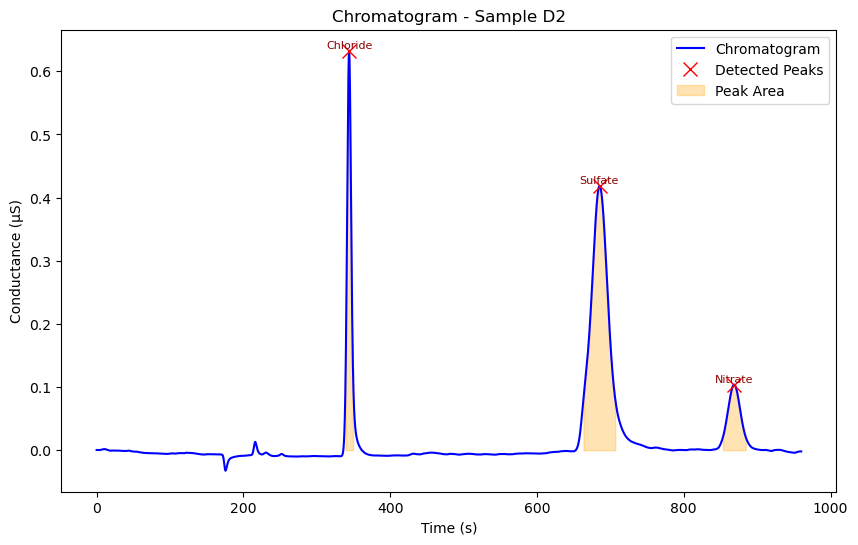

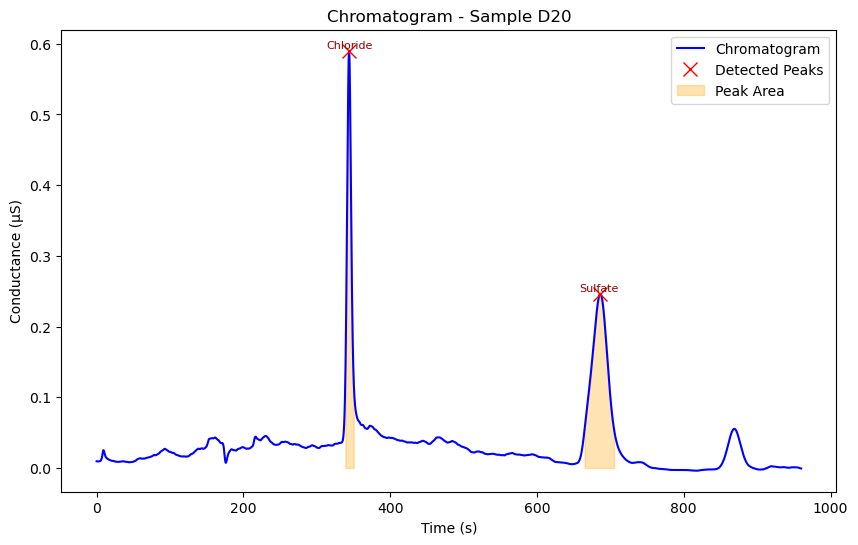

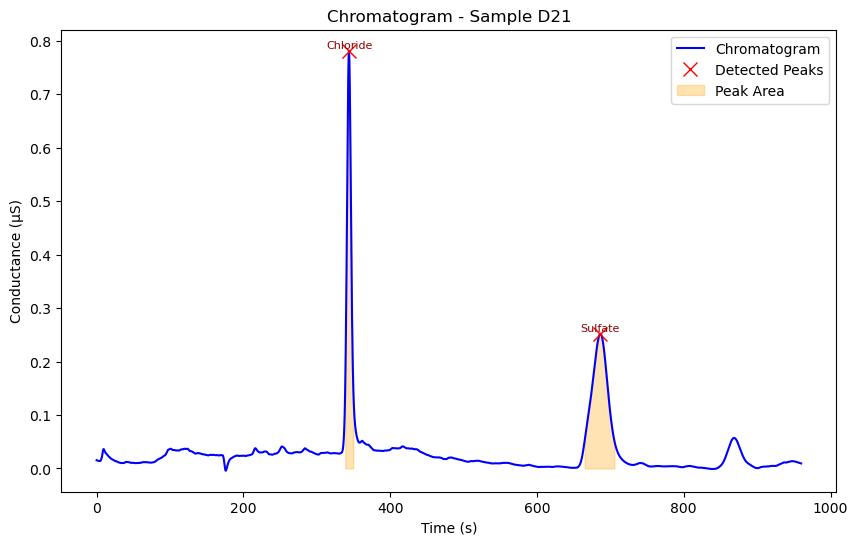

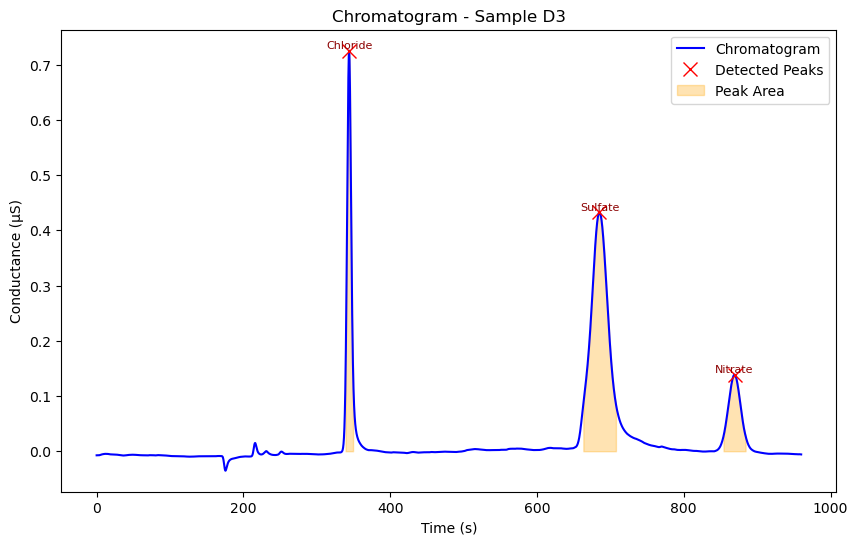

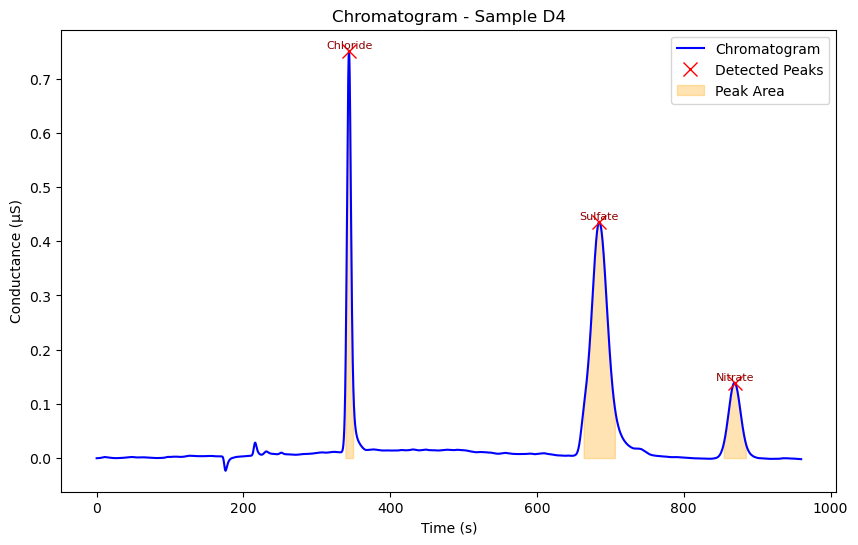

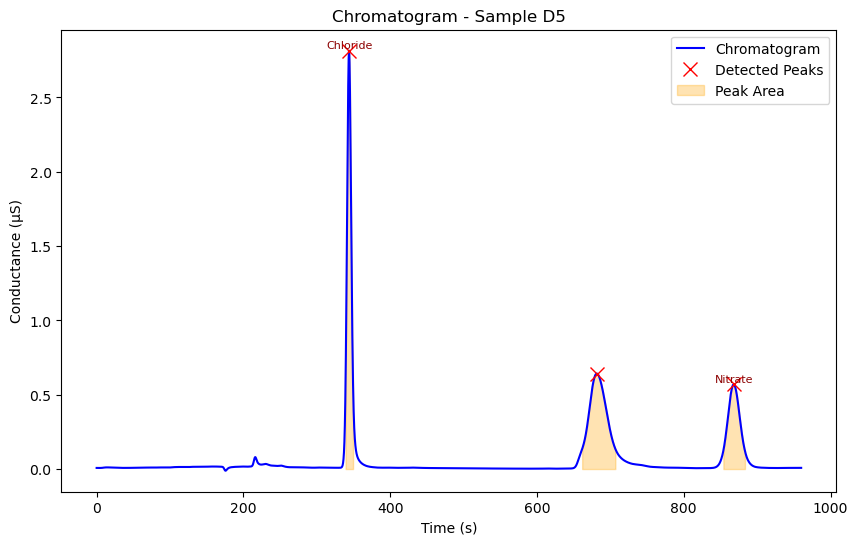

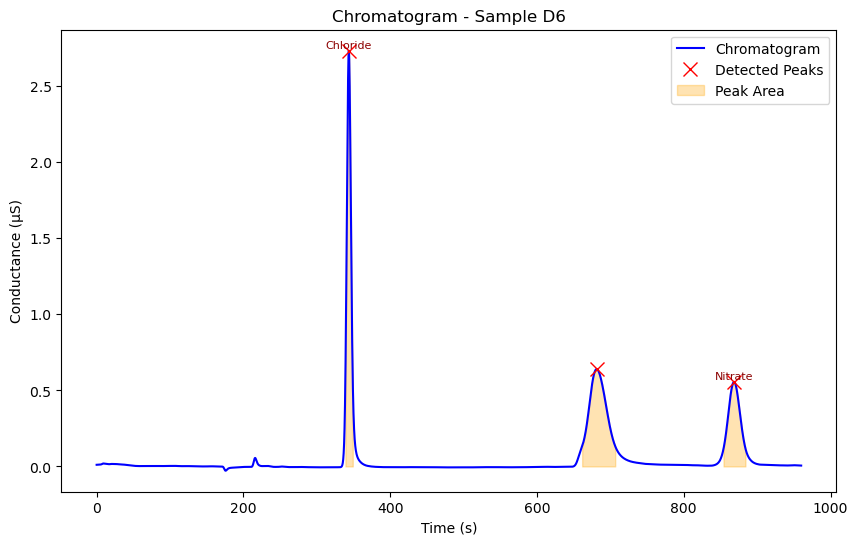

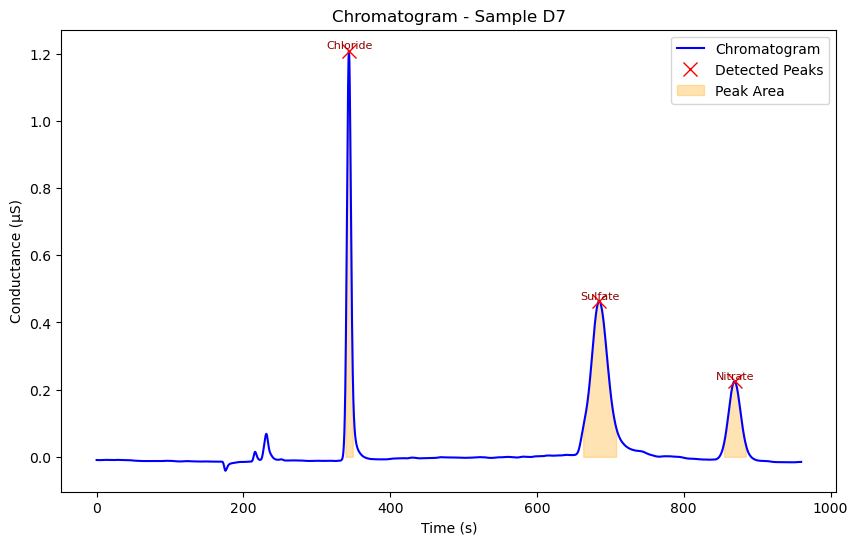

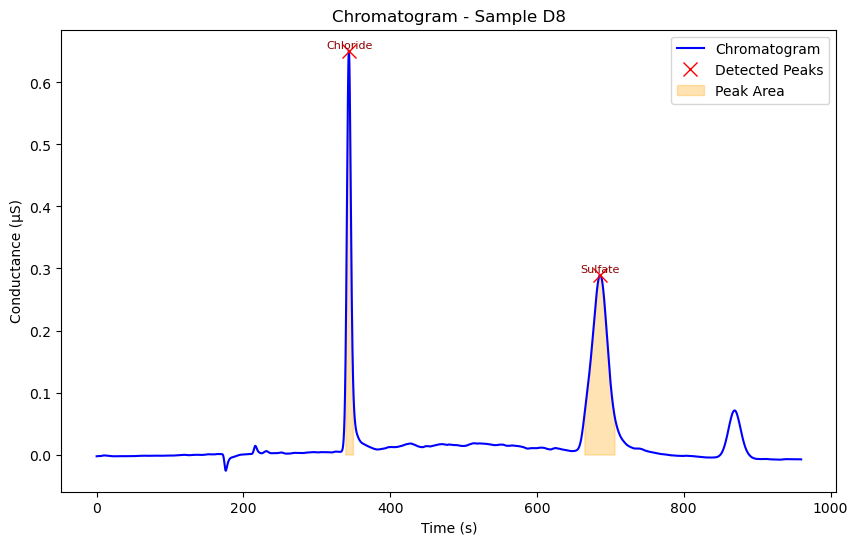

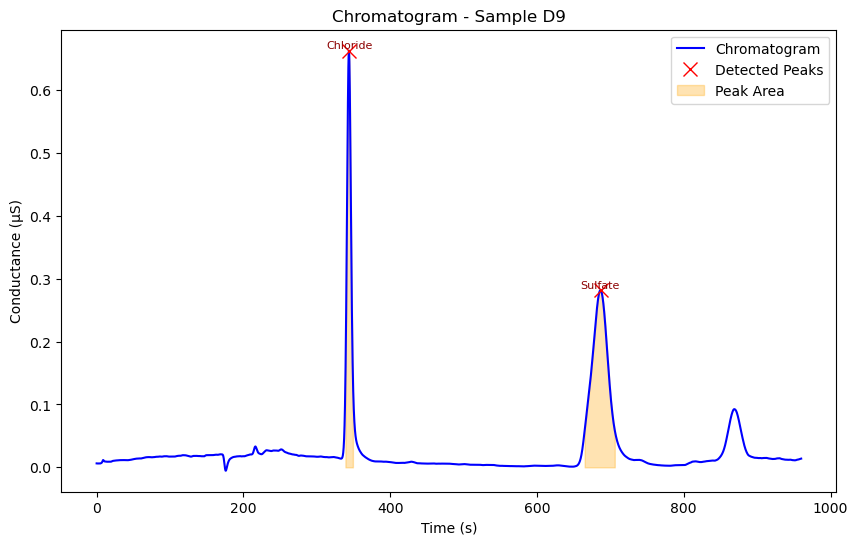

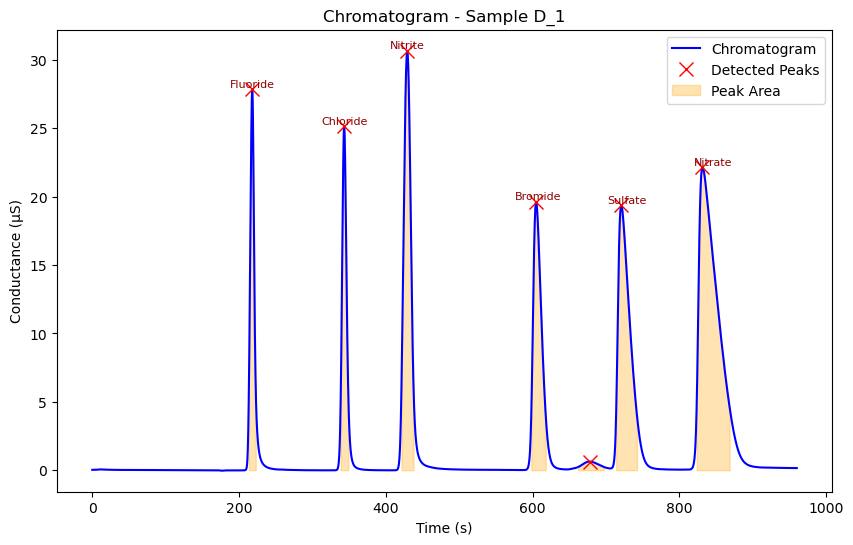

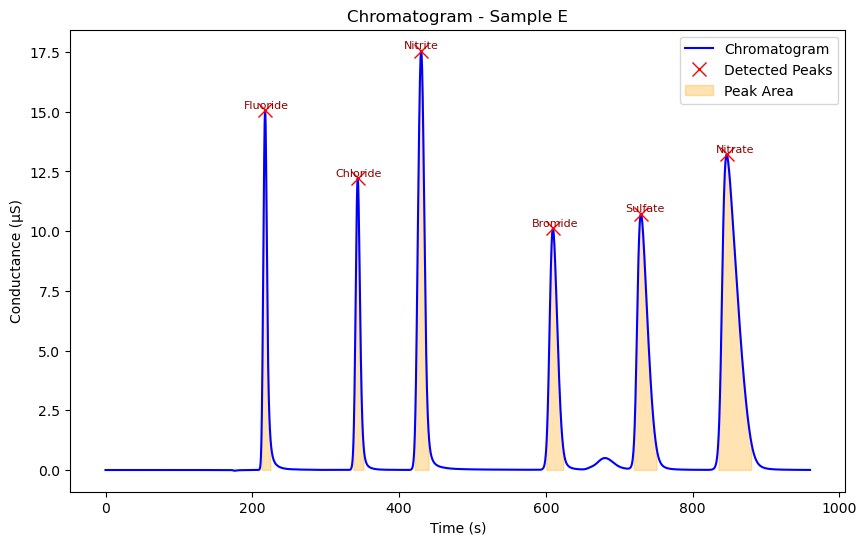

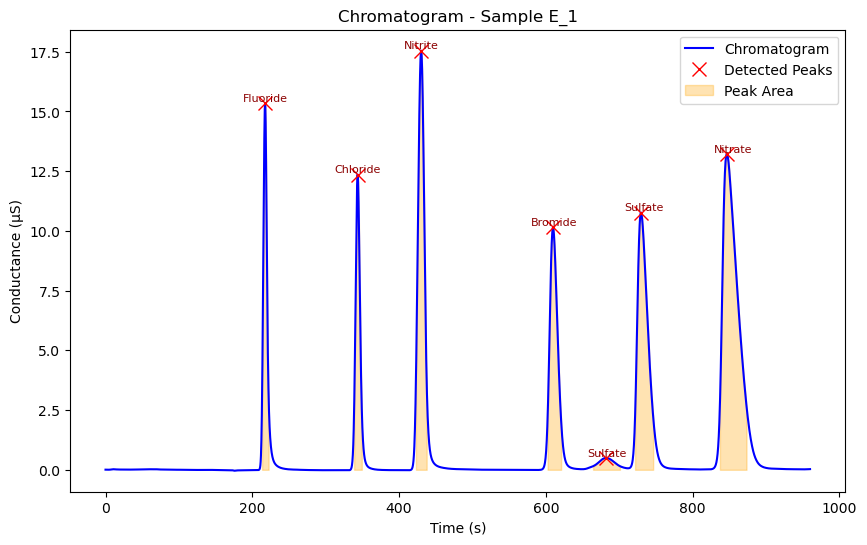

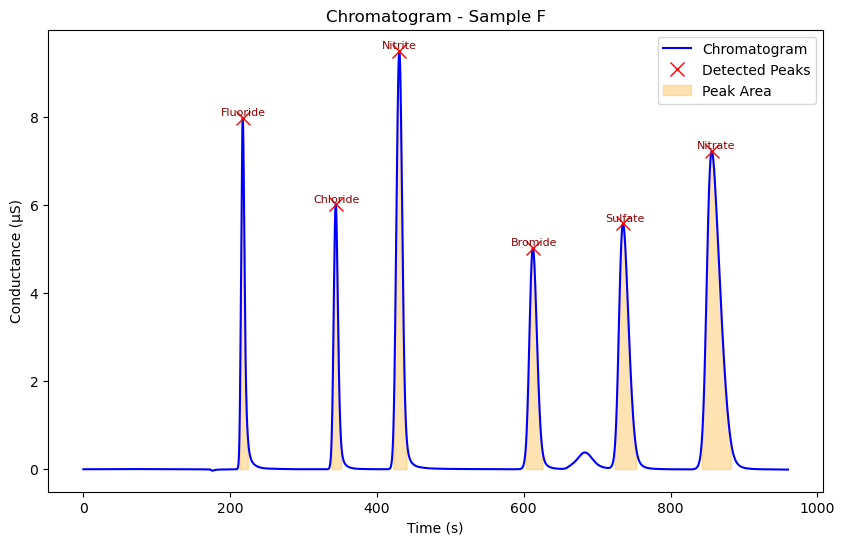

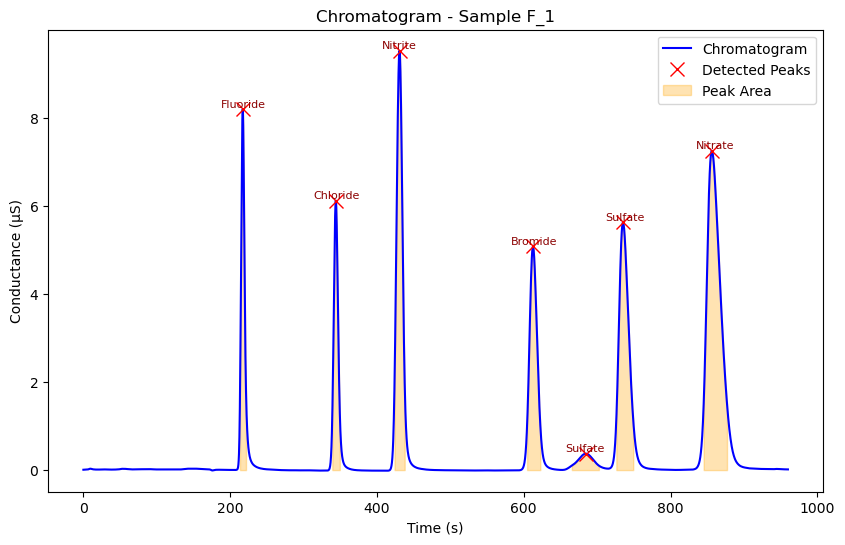

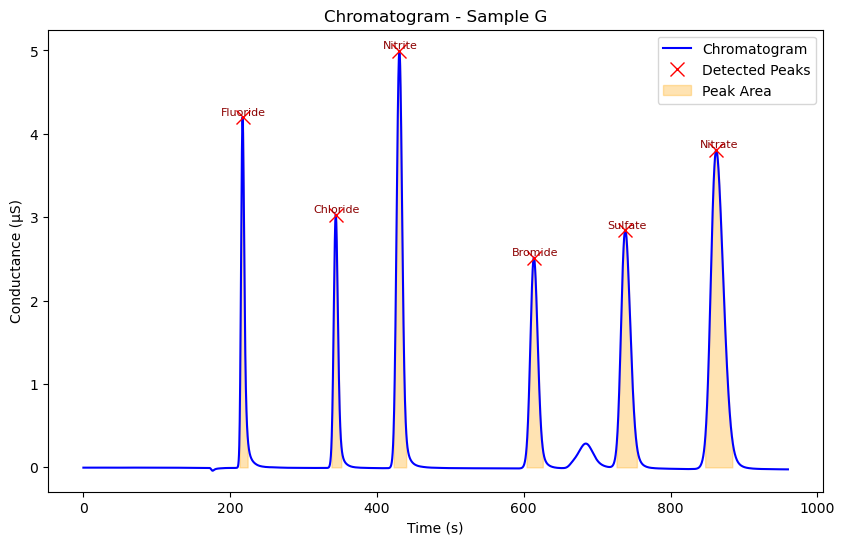

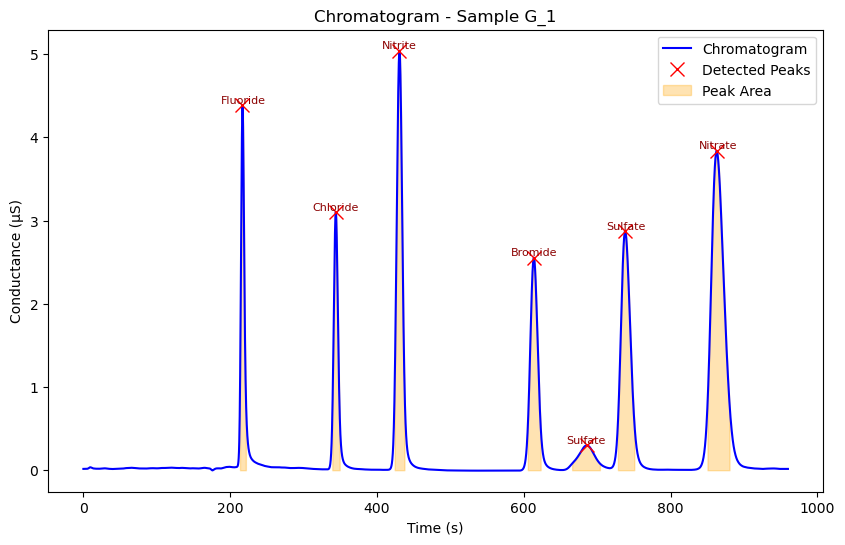

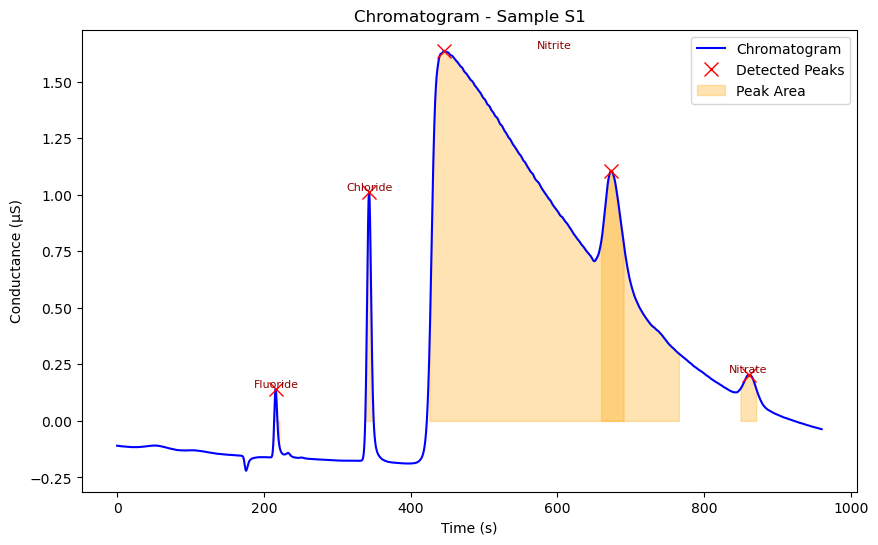

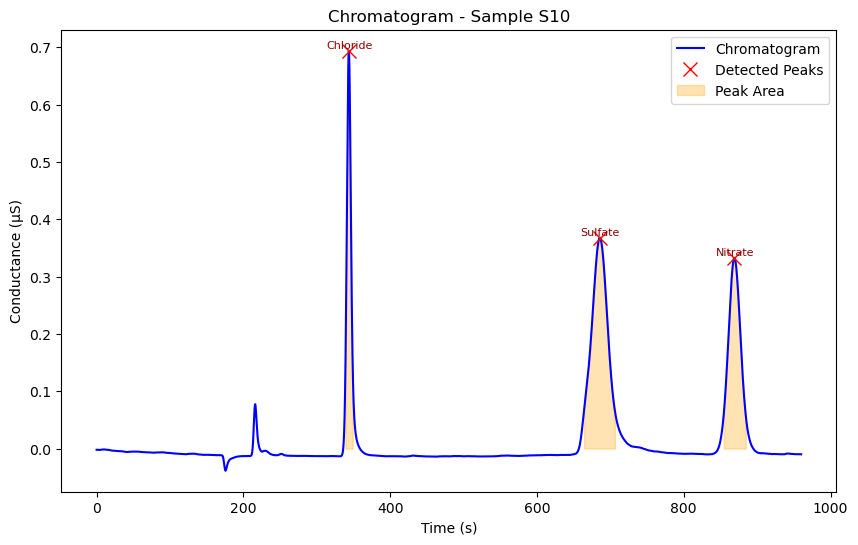

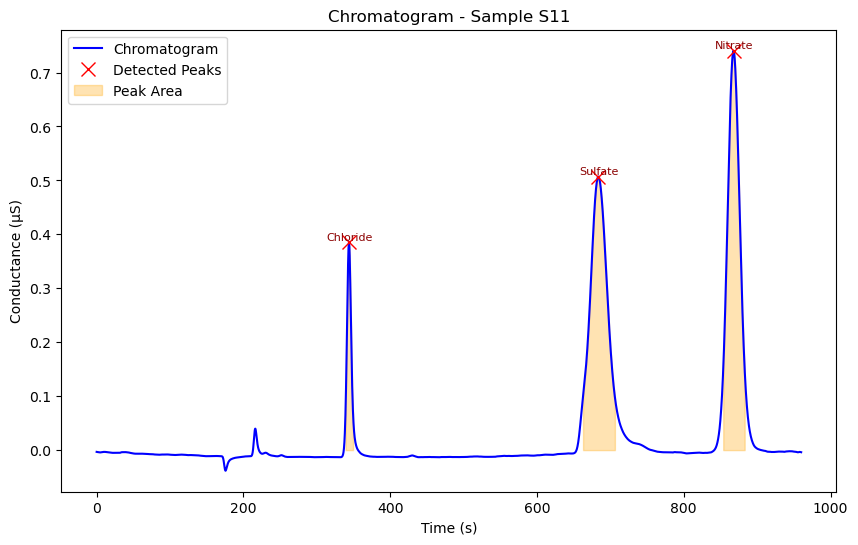

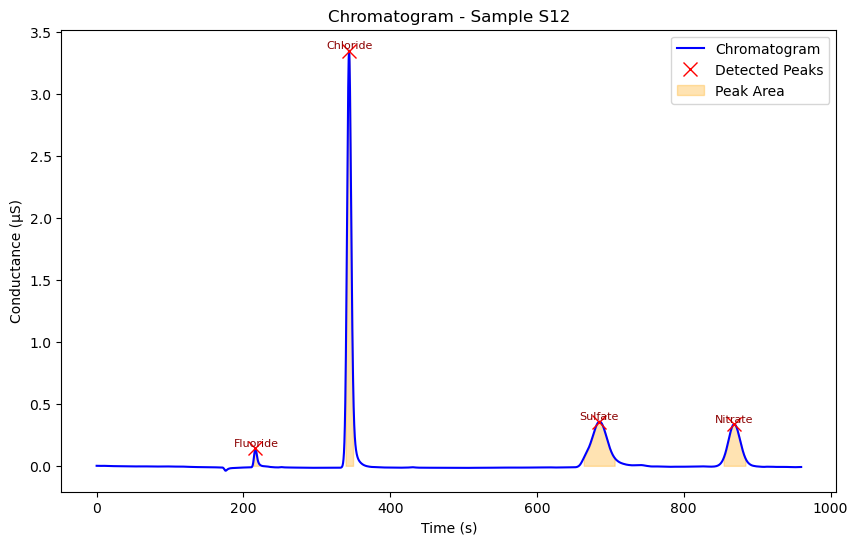

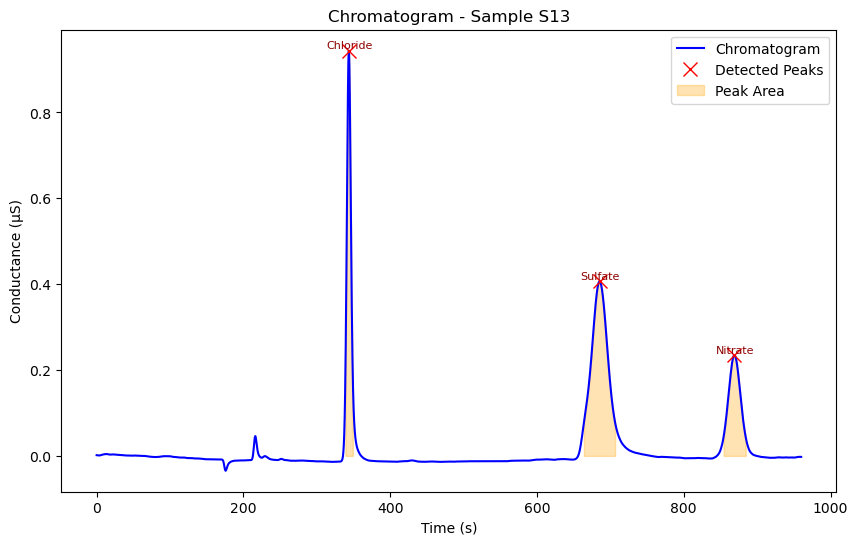

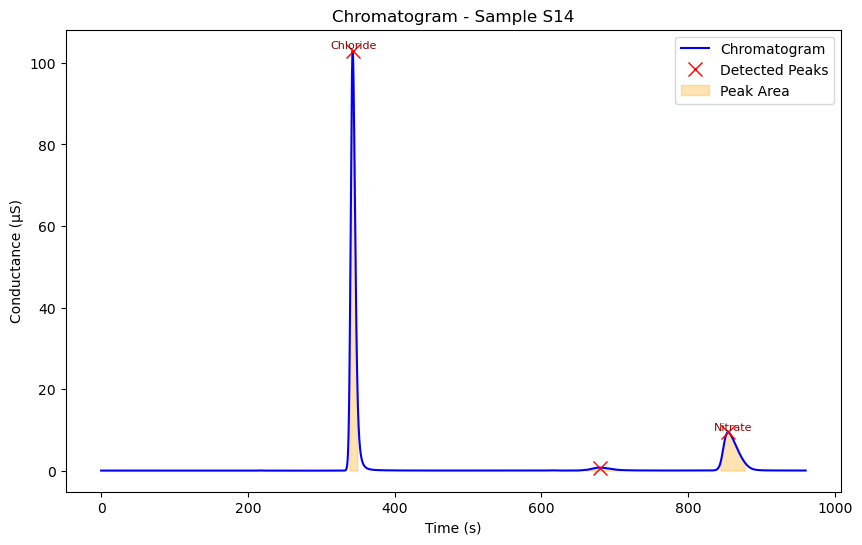

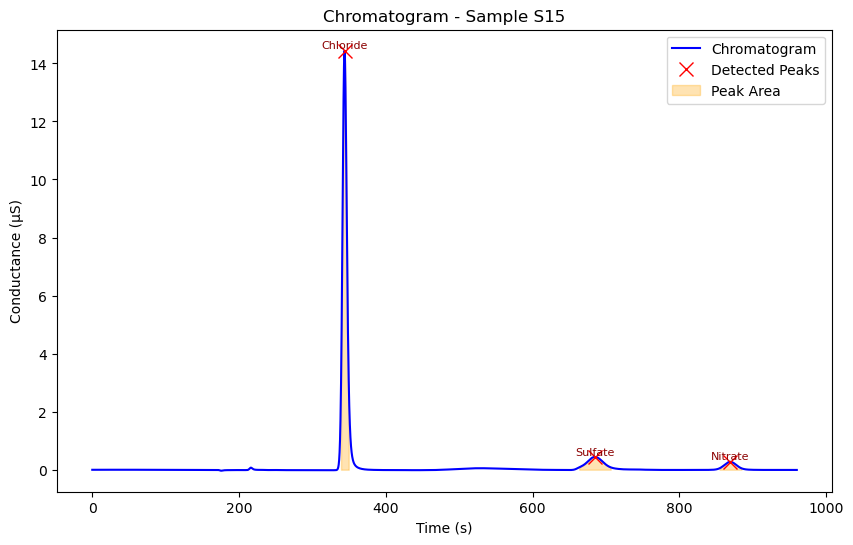

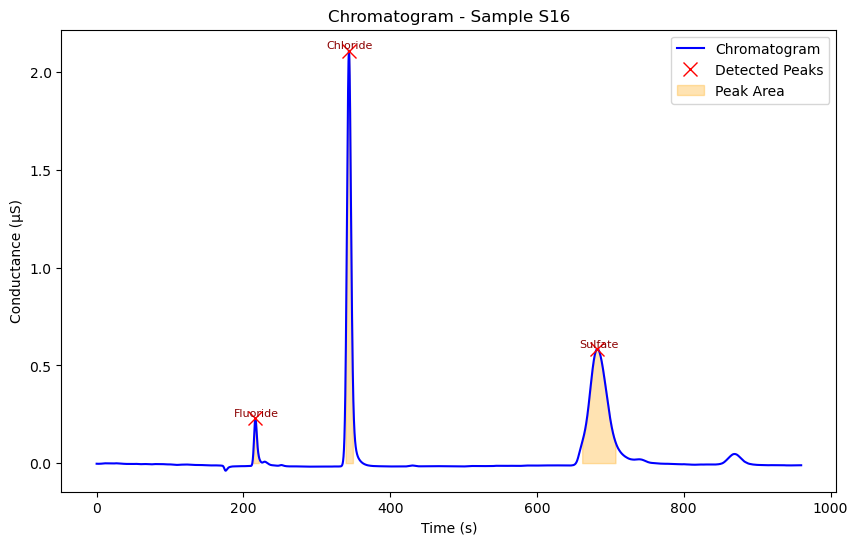

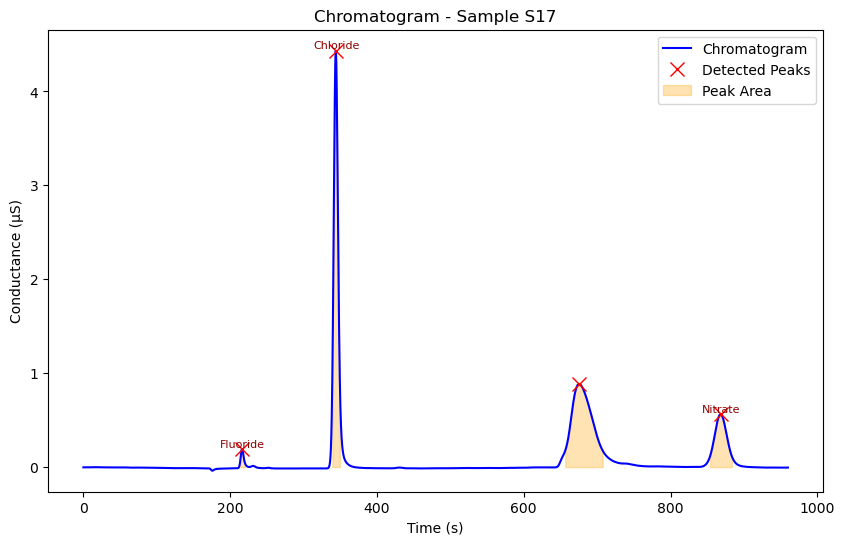

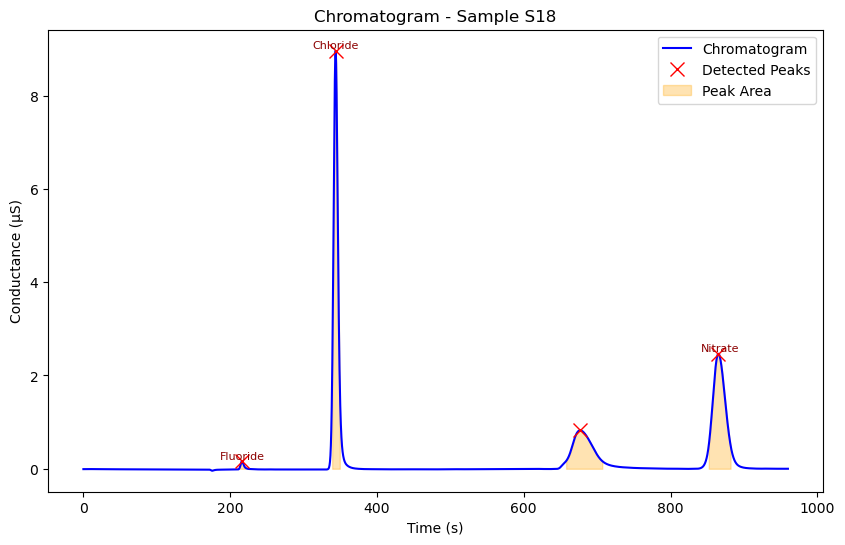

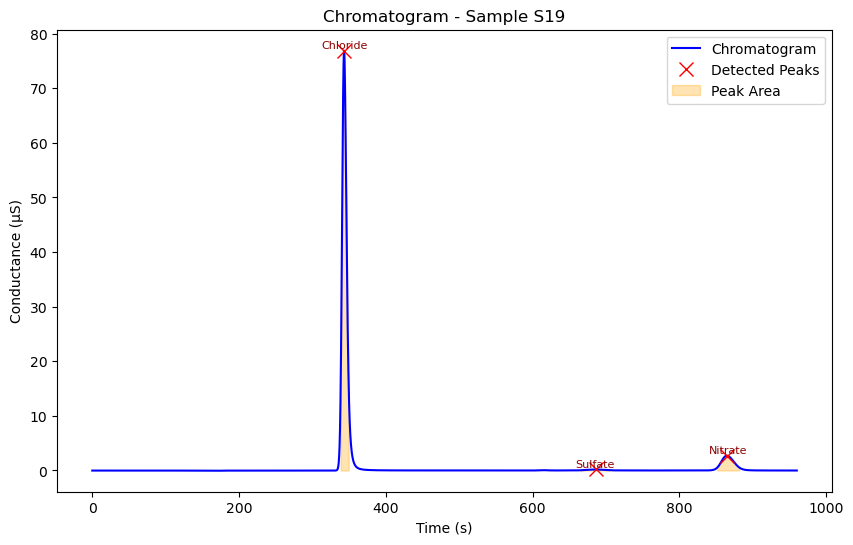

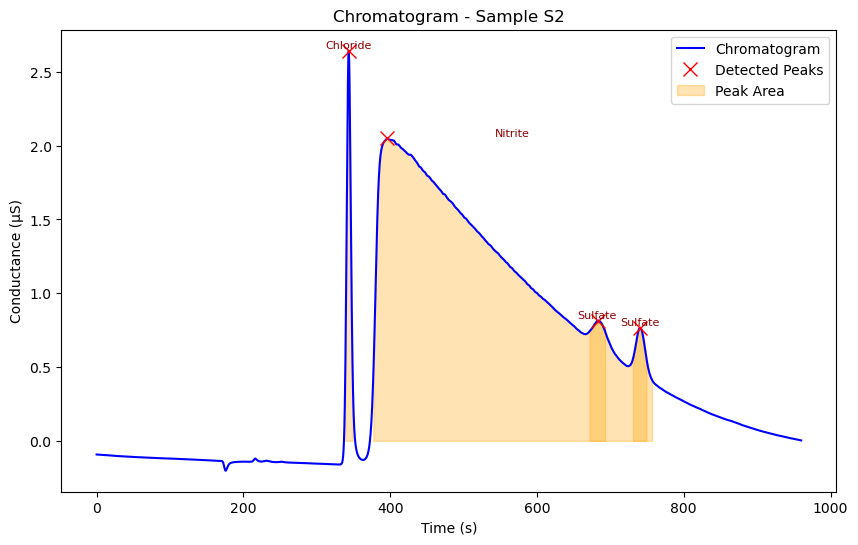

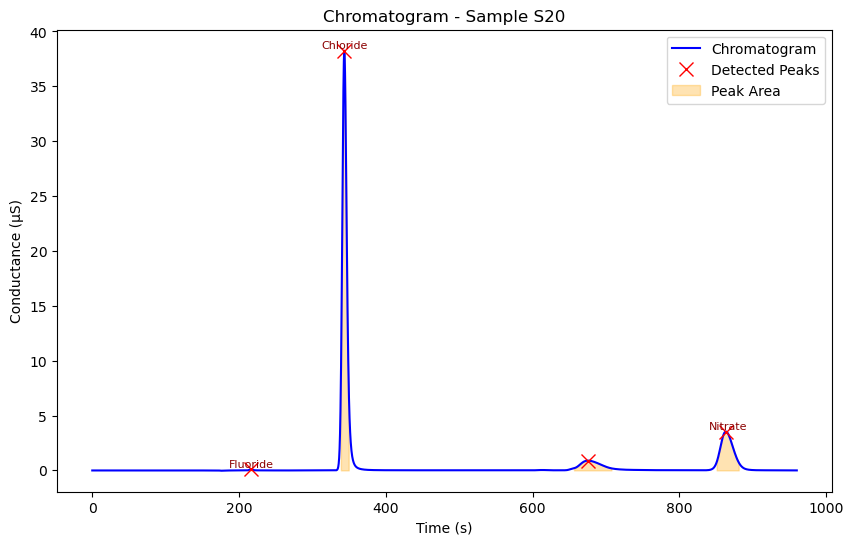

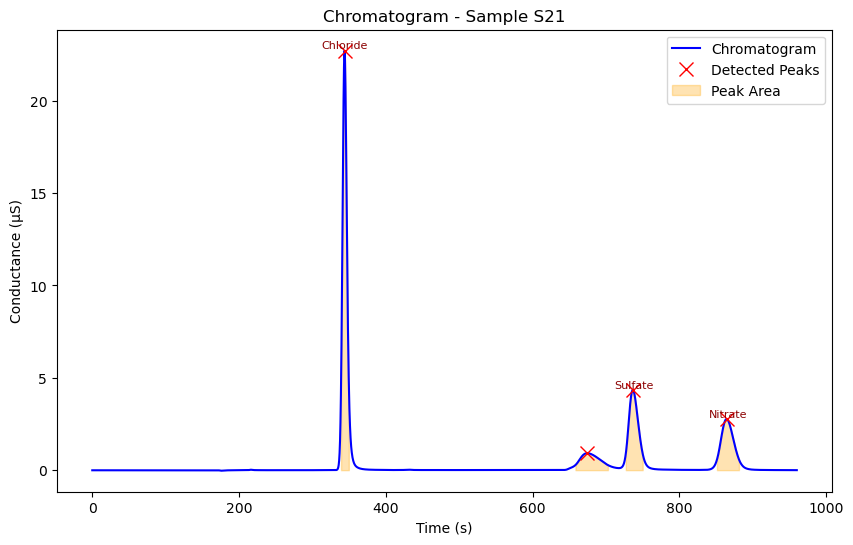

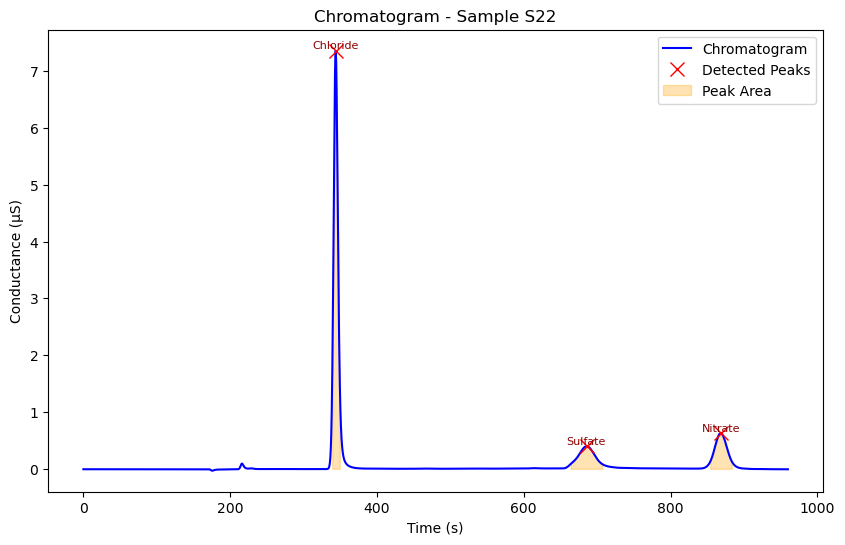

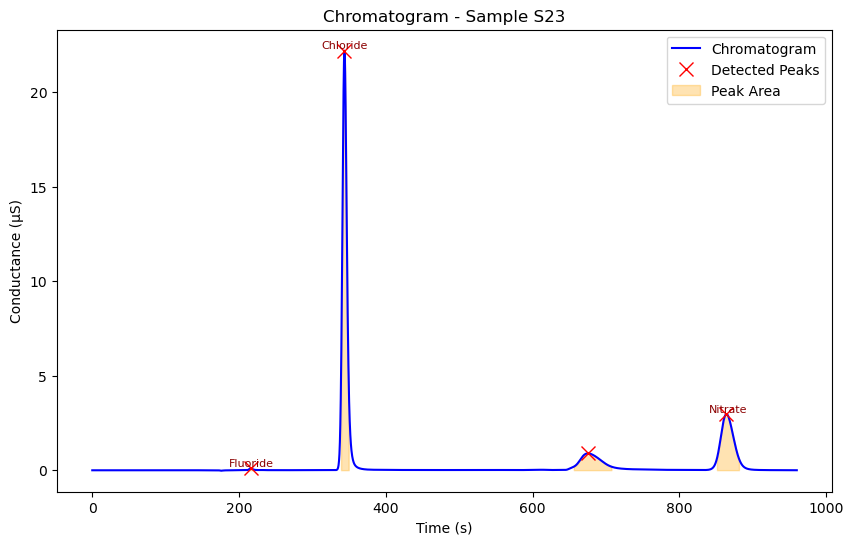

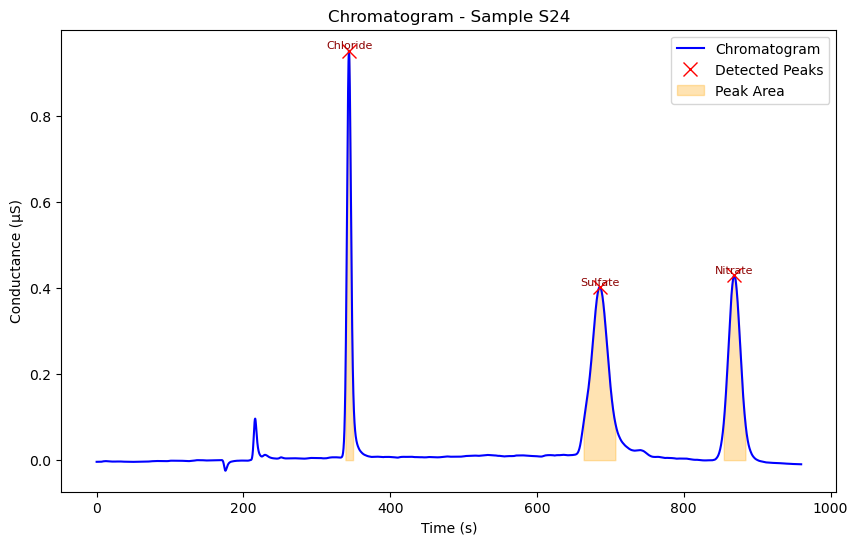

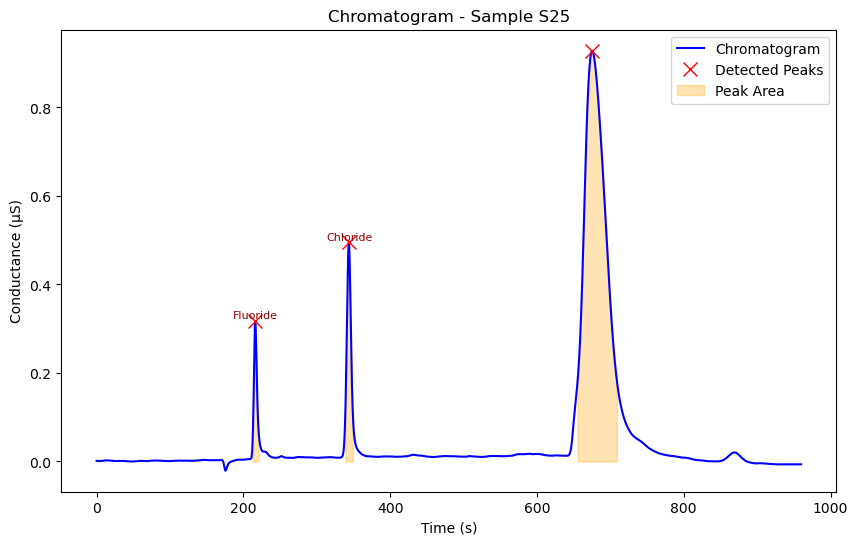

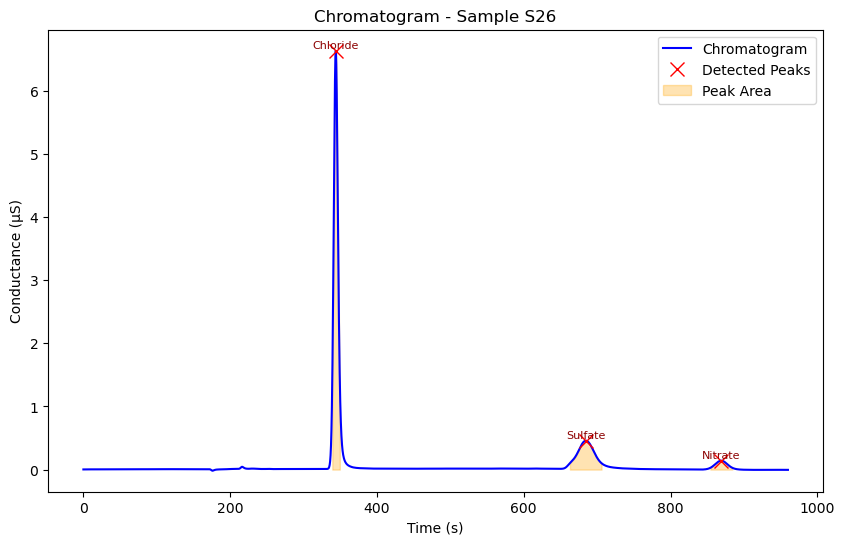

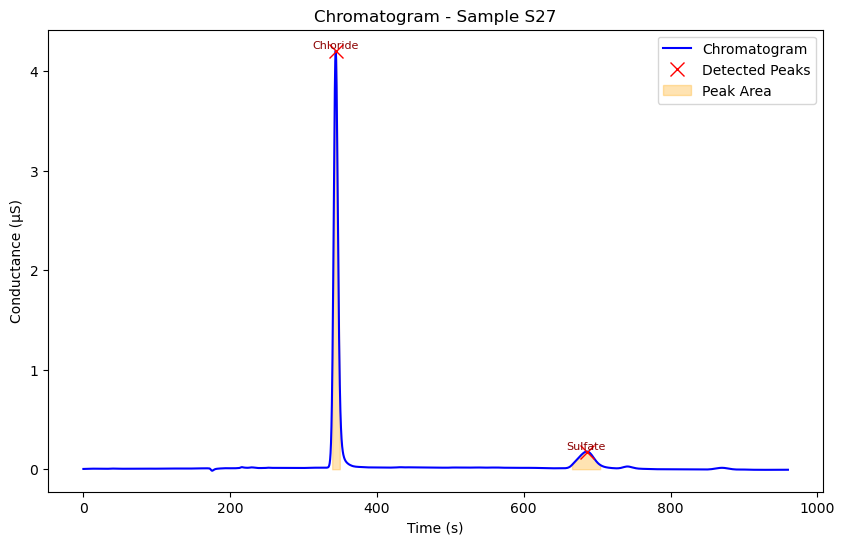

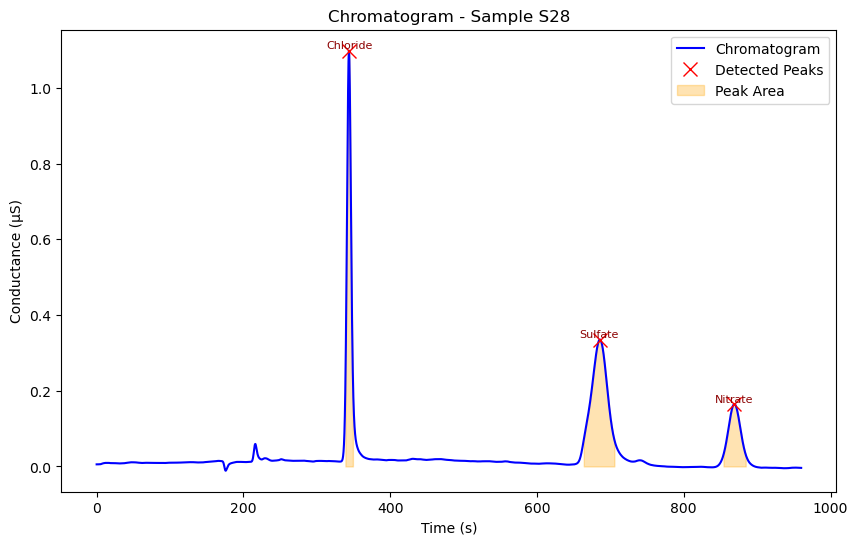

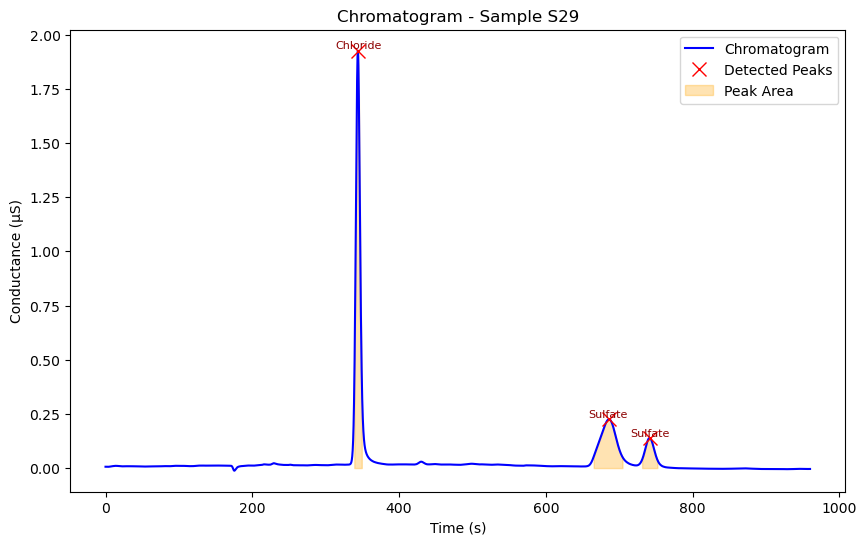

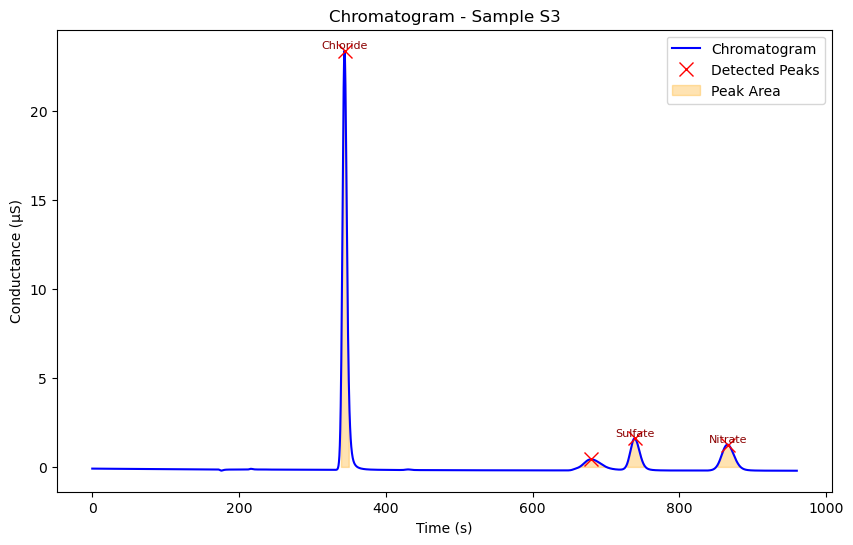

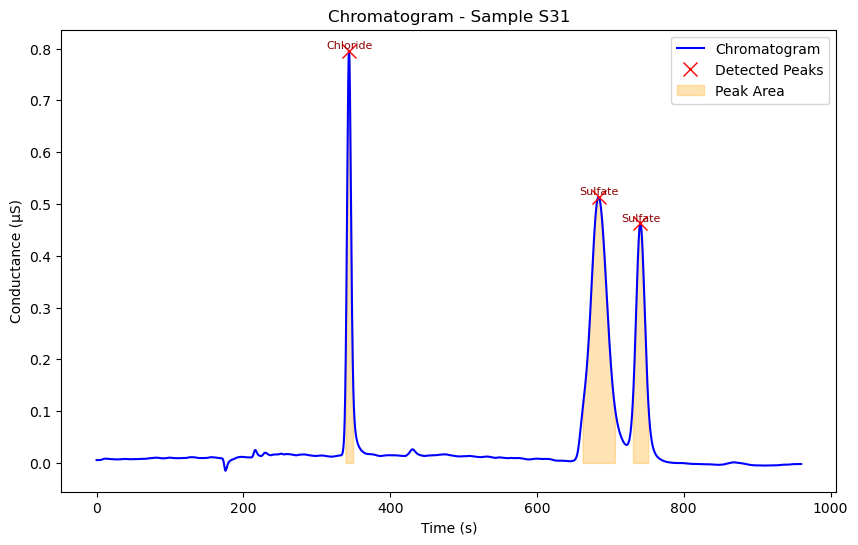

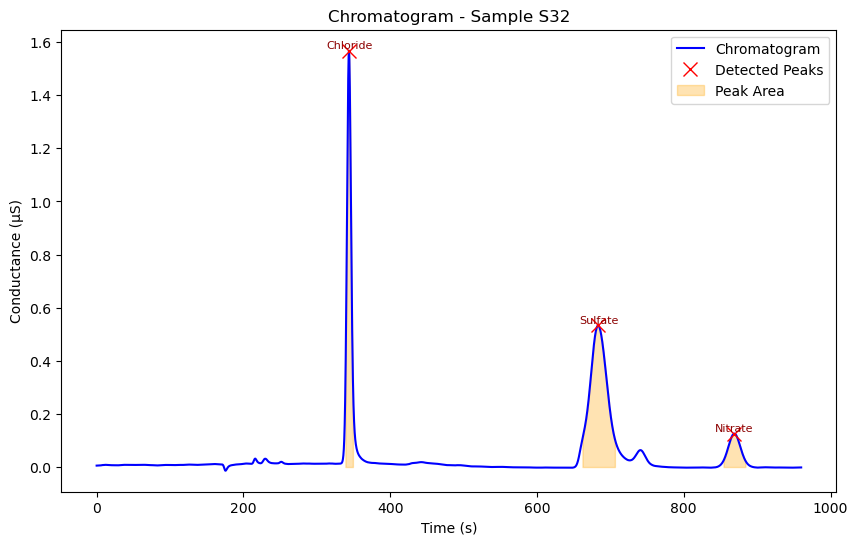

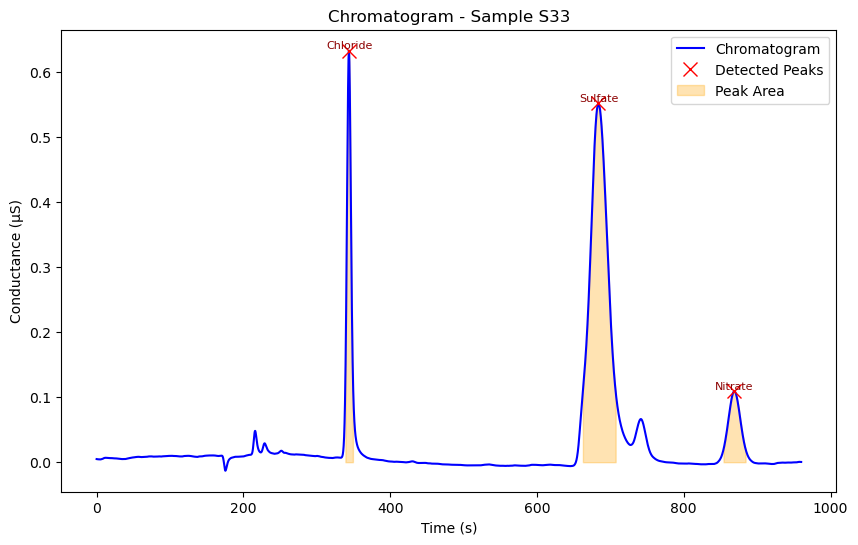

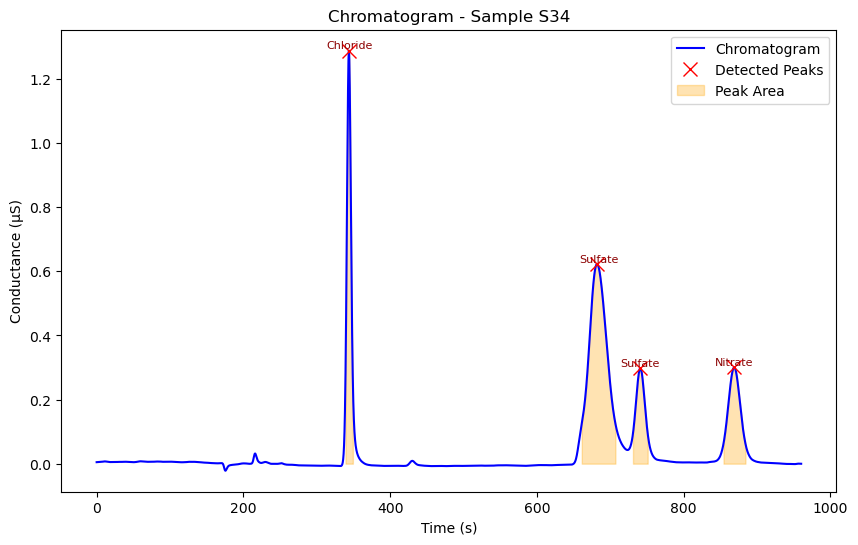

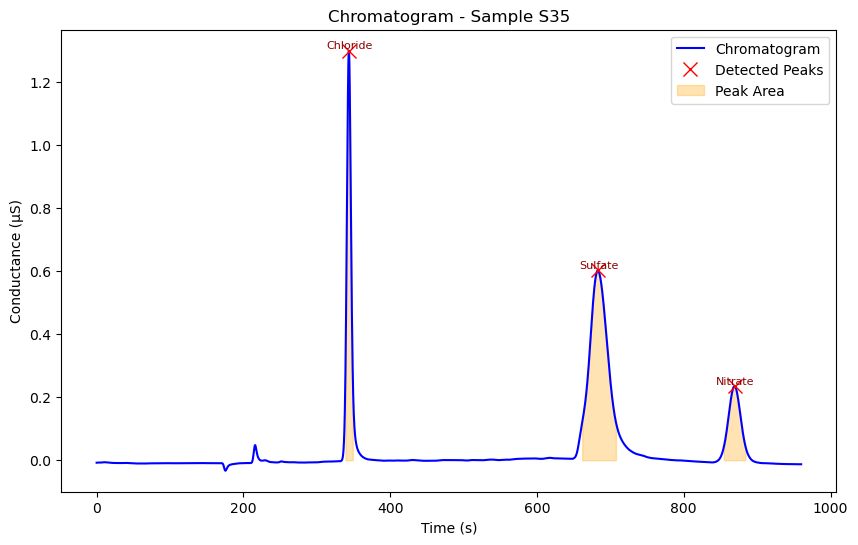

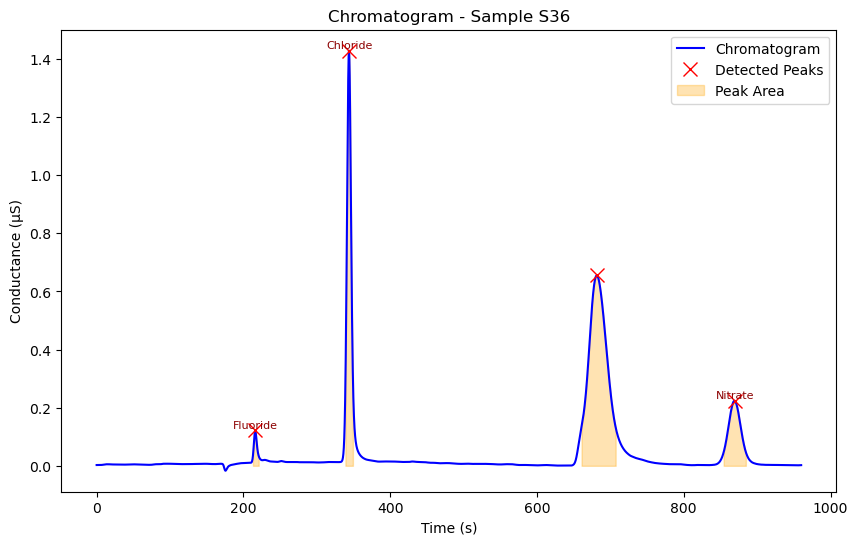

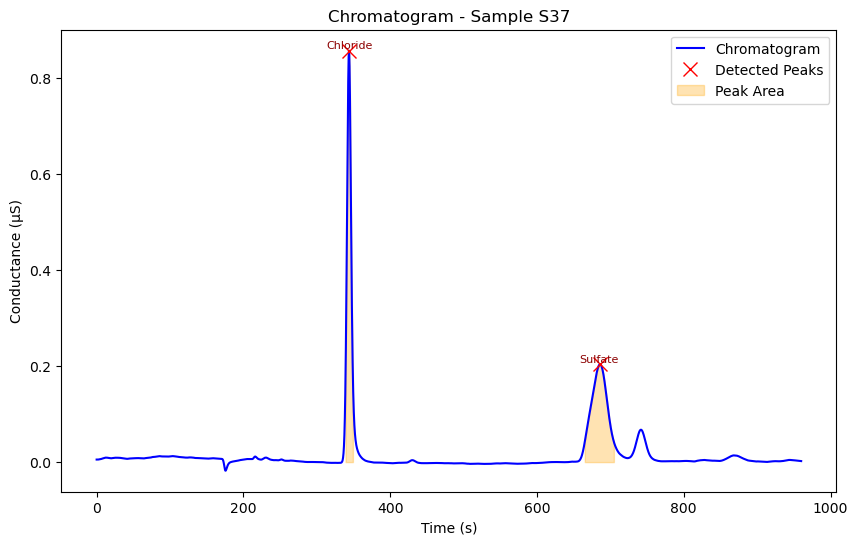

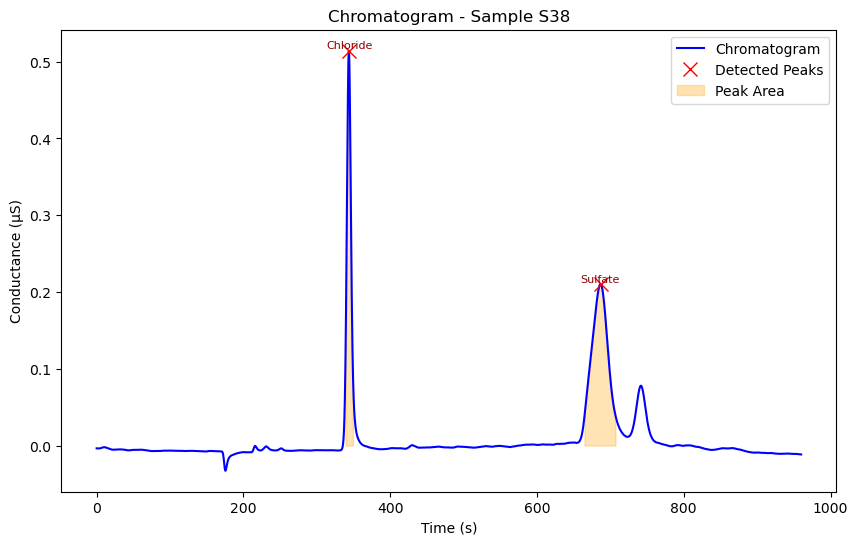

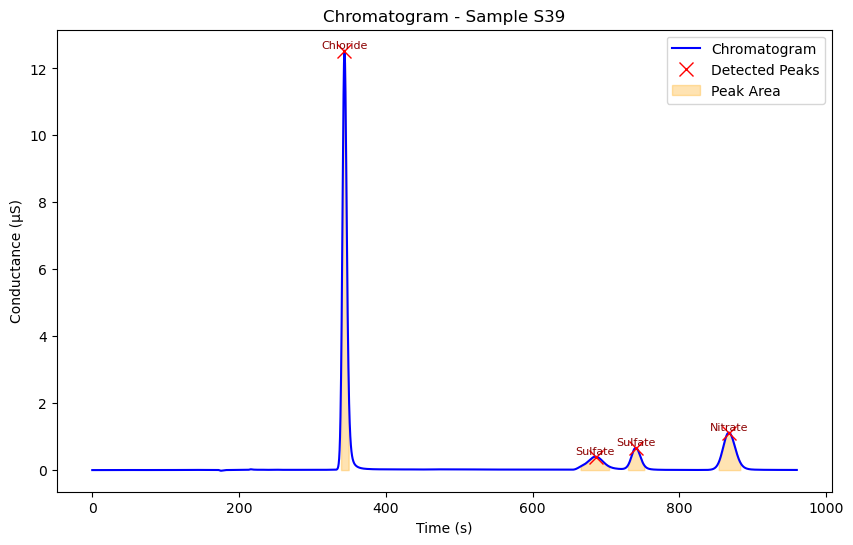

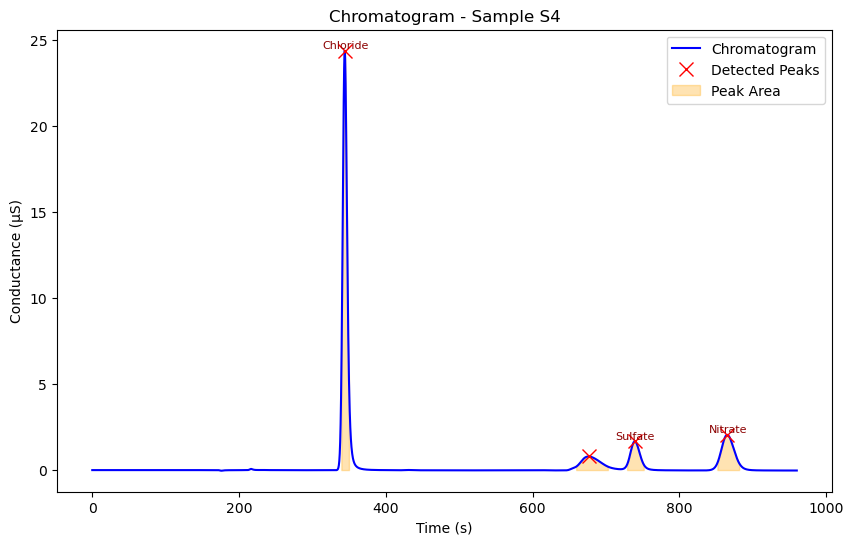

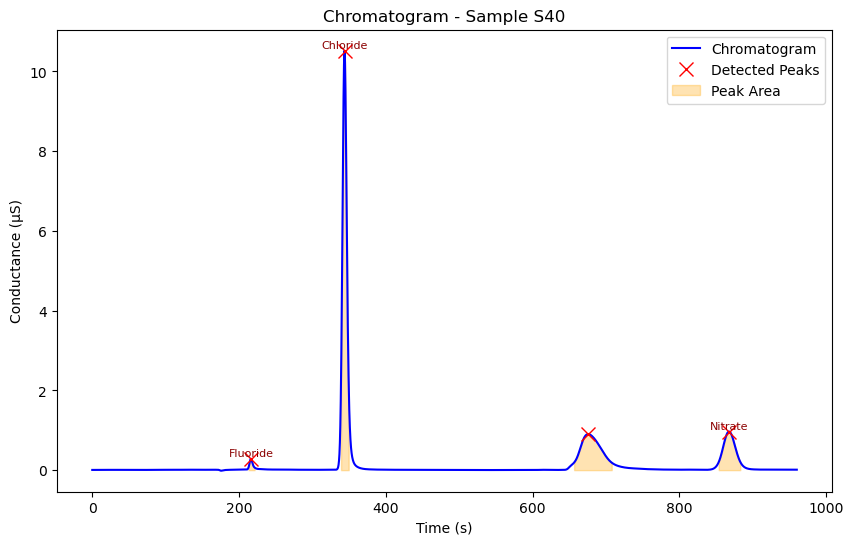

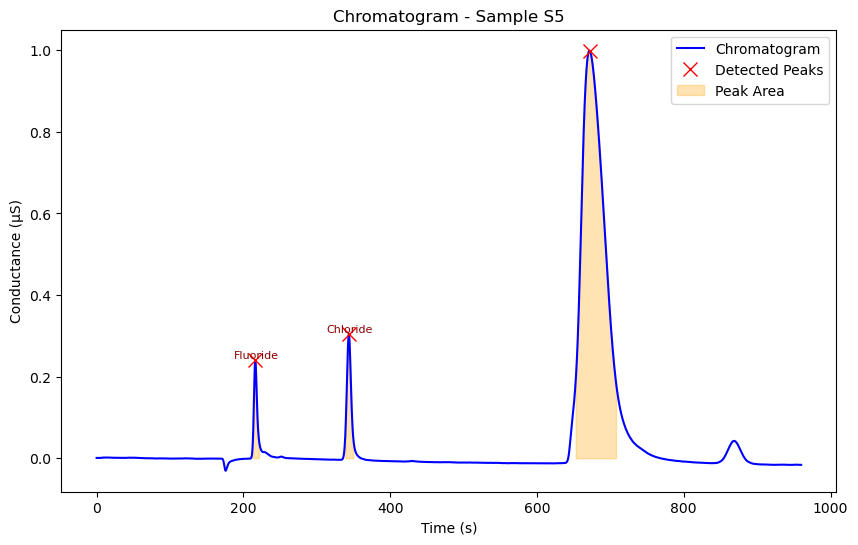

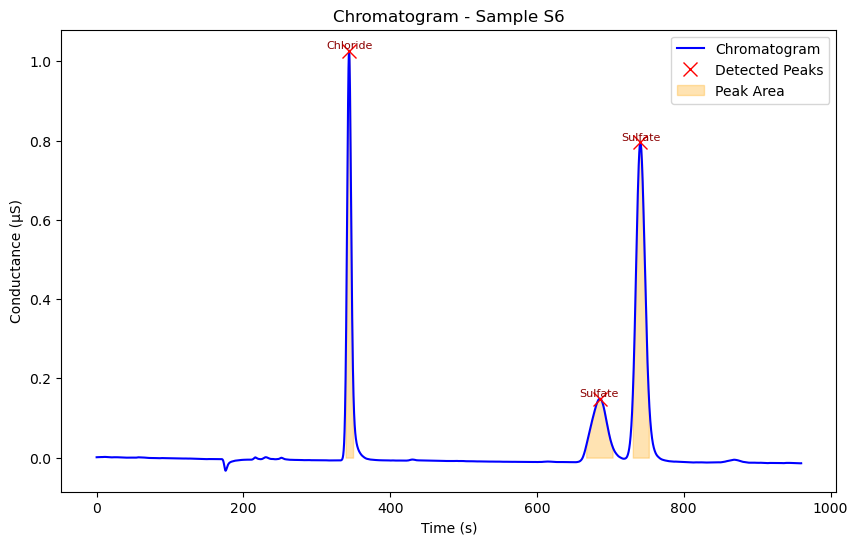

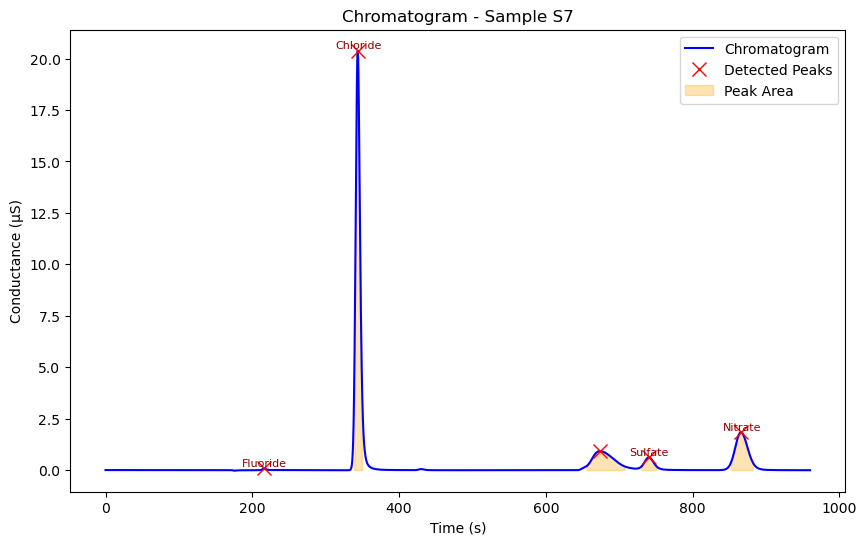

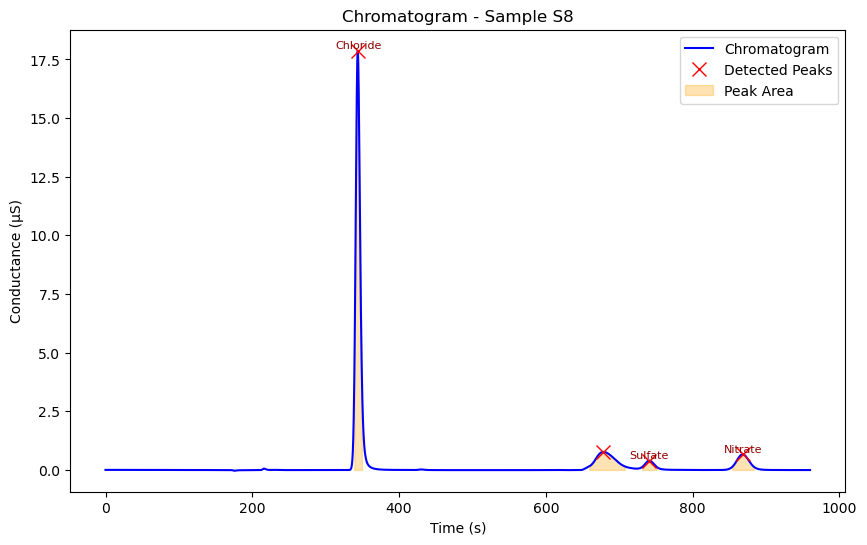

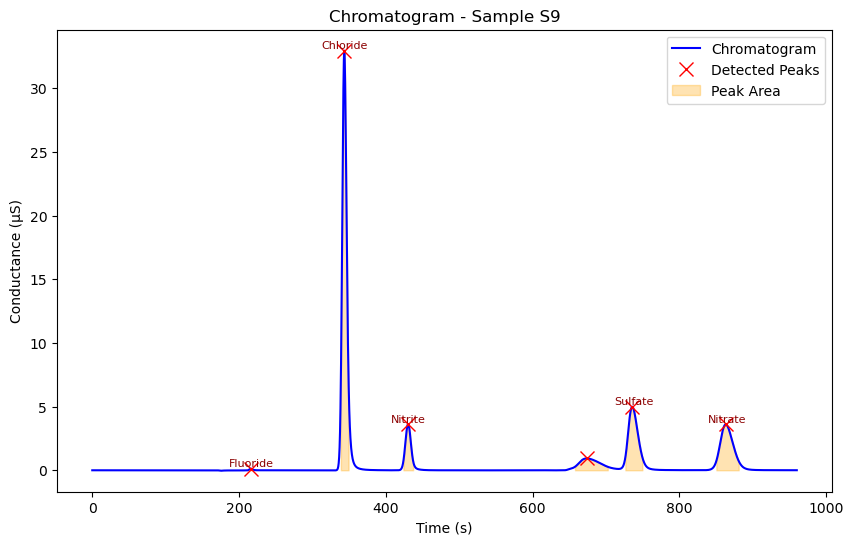

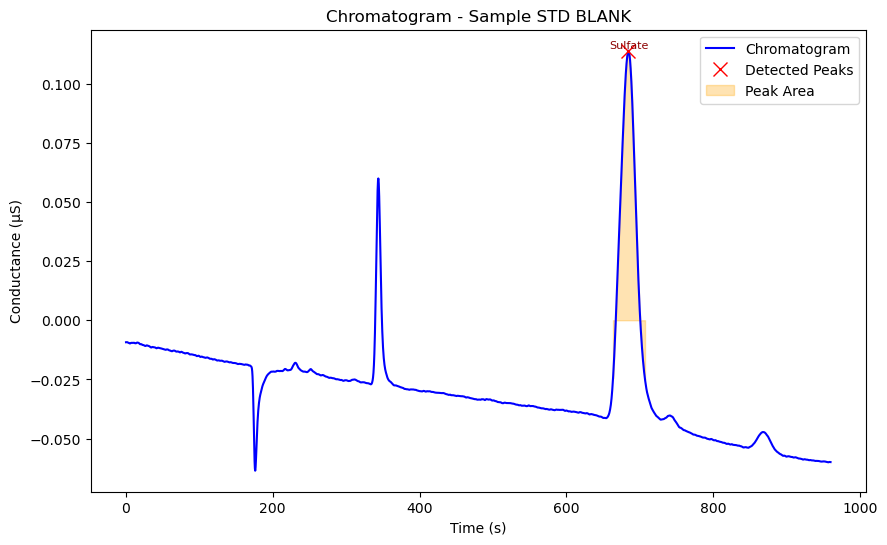

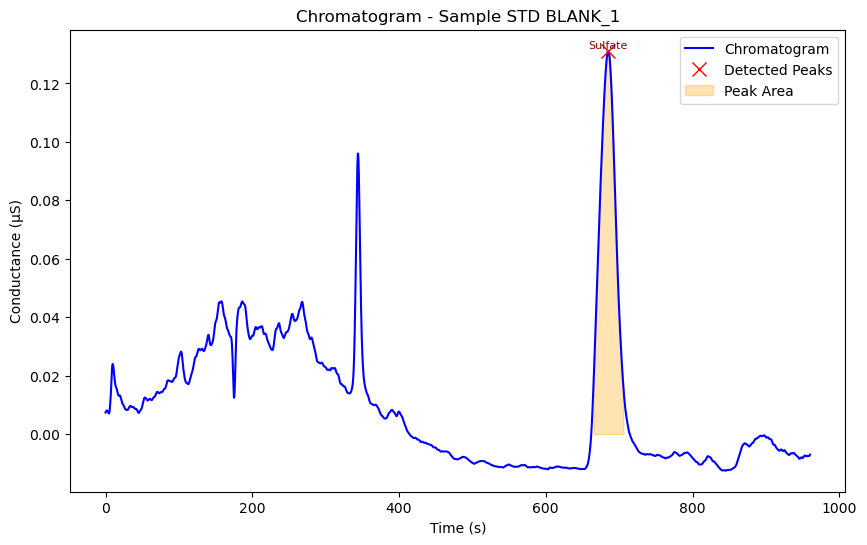

In [6]:
for sample in results_ds.coords['sample'].values:
    analyzer.plot_chromatogram(sample=sample)